# MultiSpaCE v2 Pareto Front Inspector

Step-by-step notebook for loading a `counterfactuals.pickle` run, choosing an instance, computing candidate metrics/objectives for every Pareto candidate, selecting Pareto axes next to the scatterplot, and plotting one selected CF against `x_orig` and the NUN.

In [1]:
cd ../..

/home/mrefoyo/Projects/Multi-SpaCE


In [2]:
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.auto import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output

from experiments.experiment_utils import prepare_experiment
from experiments.metrics_excel import load_outlier_calculators
from experiments.evaluation.evaluation_utils import (
    calculate_change_mask,
    ensure_cf_batch,
    infer_desired_class_for_ranking,
)
from methods.MultiSubSpaCE.FitnessFunctions import fitness_function_mo, fitness_function_mo_no_plausibility
from methods.nun_finders import GlobalNUNFinder, IndependentNUNFinder, SecondBestGlobalNUNFinder

pd.set_option('display.max_columns', 50)

2026-05-08 01:20:29.978702: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-08 01:20:30.128933: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 01:20:30.147056: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 01:20:30.147073: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above

## 1. Choose Experiment Family and Run

Set these variables like in the experiment scripts. If `EXPERIMENT_NAME` is `None`, the notebook lists all runs in the family and selects the first one unless you override it.

In [3]:
DATASET = 'ptbxl'
MODEL_TO_EXPLAIN_EXPERIMENT_NAME = 'inceptiontime_noscaling'
EXPERIMENT_FAMILY = 'multisubspace_v2_ptbxl'
EXPERIMENT_NAME = "v2_f3f682b91a67a3c7bd162bc42643e1ae656743cf"  # Example: 'v2_23c22b9d1fe7b476ad00a033915baa7518e6bfd9'

OUTLIER_CALCULATOR_EXPERIMENTS = {'AE': 'ae_basic_train'}
MO_EVAL_WEIGHTS = {'adv': 0.1, 'sparsity': 0.4 * 0.7, 'contiguity': 0.6 * 0.7, 'plausibility': 0.2}
mo_weights = np.array(list(MO_EVAL_WEIGHTS.values()), dtype=float)

family_path = Path('experiments/results') / DATASET / MODEL_TO_EXPLAIN_EXPERIMENT_NAME / EXPERIMENT_FAMILY
available_runs = sorted(path.name for path in family_path.iterdir() if (path / 'counterfactuals.pickle').is_file())
if not available_runs:
    raise FileNotFoundError(f'No counterfactuals.pickle runs found in {family_path}')
if EXPERIMENT_NAME is None:
    EXPERIMENT_NAME = available_runs[0]

result_path = family_path / EXPERIMENT_NAME
counterfactuals_path = result_path / 'counterfactuals.pickle'
params_path = result_path / 'params.json'
print(f'Available runs: {len(available_runs)}')
print(f'Using: {counterfactuals_path}')

Available runs: 1
Using: experiments/results/ptbxl/inceptiontime_noscaling/multisubspace_v2_ptbxl/v2_f3f682b91a67a3c7bd162bc42643e1ae656743cf/counterfactuals.pickle


## 2. Load Data, Model, NUNs, and Counterfactuals

In [4]:
def get_nun_strategy(params):
    if 'nun_strategy' in params:
        return params['nun_strategy']
    if params.get('independent_channels_nun', False):
        return 'independent'
    return 'global'

with params_path.open('r') as fp:
    params = json.load(fp)

X_train, y_train, X_test, y_test, subset_idx, n_classes, model_wrapper, y_pred_train, y_pred_test = prepare_experiment(
    DATASET,
    params,
    MODEL_TO_EXPLAIN_EXPERIMENT_NAME,
)

nun_strategy = get_nun_strategy(params)
nun_model_wrapper = model_wrapper if nun_strategy in {'independent', 'second_best'} else None
if nun_strategy == 'independent':
    nun_finder = IndependentNUNFinder(
        X_train, y_train, y_pred_train, distance='euclidean', from_true_labels=False,
        backend='tf', n_neighbors=params['n_neighbors'], model=nun_model_wrapper,
    )
elif nun_strategy == 'second_best':
    nun_finder = SecondBestGlobalNUNFinder(
        X_train, y_train, y_pred_train, distance='euclidean', from_true_labels=False,
        backend='tf', model=nun_model_wrapper,
    )
elif nun_strategy == 'global':
    nun_finder = GlobalNUNFinder(
        X_train, y_train, y_pred_train, distance='euclidean', from_true_labels=False, backend='tf'
    )
else:
    raise ValueError(f'Unsupported nun_strategy: {nun_strategy}')

nuns, desired_classes, distances = nun_finder.retrieve_nuns(X_test, y_pred_test)
nuns = nuns[:, 0, :, :]

with counterfactuals_path.open('rb') as fp:
    solutions = pickle.load(fp)

outlier_calculators = load_outlier_calculators(DATASET, X_train, OUTLIER_CALCULATOR_EXPERIMENTS)
ae_outlier_calculator = outlier_calculators.get('AE')

print(f'Loaded {len(solutions)} explained instances')
print(f'X_test shape: {X_test.shape}; NUN shape: {nuns.shape}; calculators: {list(outlier_calculators)}')

2026-05-08 01:20:32.466827: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 01:20:32.473063: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 01:20:32.479708: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 01:20:32.479819: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-05-08 01:20:32.479915: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not lo

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        34
           1       1.00      0.92      0.96        66

    accuracy                           0.95       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.96      0.95      0.95       100

Loaded 100 explained instances
X_test shape: (100, 175, 15); NUN shape: (100, 175, 15); calculators: ['AE']


## 3. Select Instance to Explain

## 4. Calculate Metrics and Objectives for All Candidates

This mirrors the metric/objective logic used by `calculate_method_metrics`, but it keeps every candidate instead of choosing the best one with the MO utility.

In [5]:
def calculate_candidate_metrics_for_instance(instance_pos):
    solution = solutions[instance_pos]
    length = X_test.shape[1]
    n_channels = X_test.shape[2]
    cfs = ensure_cf_batch(solution['cfs'] if 'cfs' in solution else solution['cf'], length, n_channels)
    x_orig = X_test[instance_pos]
    x_nun = nuns[instance_pos]
    original_class = y_pred_test[instance_pos]
    true_class = y_test[instance_pos]
    execution_time = solution.get('time', np.nan)

    predicted_probs = model_wrapper.predict(cfs)
    pred_classes = np.argmax(predicted_probs, axis=1)
    desired_class = int(np.argmax(model_wrapper.predict(np.expand_dims(x_nun, axis=0)), axis=1)[0])
    desired_class_probs = predicted_probs[:, desired_class]
    valid = (pred_classes != original_class) & (~np.isnan(cfs).reshape(cfs.shape[0], -1).any(axis=1))

    change_masks = np.stack([
        calculate_change_mask(x_orig, cf.reshape(length, n_channels), x_nun=x_nun, verbose=0)
        for cf in cfs
    ], axis=0)
    nchanges = change_masks.sum(axis=(1, 2))
    sparsity = nchanges / (length * n_channels)
    subsequences = np.count_nonzero(np.diff(change_masks, prepend=0, axis=1) == 1, axis=(1, 2))
    subsequences_pct = subsequences / ((length * n_channels) / 2)
    l1 = np.linalg.norm((cfs - x_orig).reshape(cfs.shape[0], -1), ord=1, axis=1)
    l2 = np.linalg.norm((cfs - x_orig).reshape(cfs.shape[0], -1), ord=2, axis=1)

    if ae_outlier_calculator is not None:
        ae_os = ae_outlier_calculator.get_outlier_scores(cfs)
        ae_orig = ae_outlier_calculator.get_outlier_scores(np.expand_dims(x_orig, axis=0))[0]
        ae_ios = ae_os - ae_orig
        ae_ios[ae_ios < 0] = 0
    else:
        ae_os = np.full(cfs.shape[0], np.nan)
        ae_ios = np.full(cfs.shape[0], np.nan)

    utility_outlier_scores = ae_os if ae_outlier_calculator is not None else np.zeros(cfs.shape[0])
    utility_original_outlier_score = ae_orig if ae_outlier_calculator is not None else 0
    if len(mo_weights) == 3:
        objective_fitness = fitness_function_mo_no_plausibility(change_masks, predicted_probs, desired_class, utility_outlier_scores, utility_original_outlier_score, 100)
    elif len(mo_weights) == 4:
        objective_fitness = fitness_function_mo(change_masks, predicted_probs, desired_class, utility_outlier_scores, utility_original_outlier_score, 100)
    else:
        objective_fitness = np.full((cfs.shape[0], len(mo_weights)), np.nan)
    utility = (objective_fitness * mo_weights).sum(axis=1) if objective_fitness.shape[1] == len(mo_weights) else np.full(cfs.shape[0], np.nan)

    df = pd.DataFrame({
        'candidate_id': np.arange(cfs.shape[0]),
        'valid': valid,
        'pred_class': pred_classes,
        'true_class': true_class,
        'original_class': original_class,
        'target_class': desired_class,
        'desired_class_prob': desired_class_probs,
        'proba': predicted_probs[np.arange(cfs.shape[0]), pred_classes],
        'nchanges': nchanges,
        'sparsity': sparsity,
        'L1': l1,
        'L2': l2,
        'proximity': l2,
        'subsequences': subsequences,
        'subsequences %': subsequences_pct,
        'NoS': subsequences,
        'contiguity': subsequences_pct,
        '(sparsity + subsequences %) / 2': (sparsity + subsequences_pct**0.25) / 2,
        'AE_OS': ae_os,
        'AE_IOS': ae_ios,
        'utility': utility,
        'times': execution_time,
    })
    return df, cfs, x_orig, x_nun



In [6]:
def plot_candidate_overlay(candidate_id, height_per_channel=40):
    x_cf = candidate_cfs[int(candidate_id)]
    n_channels = x_orig.shape[1]
    fig = make_subplots(rows=n_channels, cols=1, shared_xaxes=True, vertical_spacing=0.02)
    time = np.arange(x_orig.shape[0])
    for channel in range(n_channels):
        row = channel + 1
        fig.add_trace(go.Scatter(x=time, y=x_nun[:, channel], mode='lines', name='NUN', line={'color': '#2ca02c', 'dash': 'dot'}, legendgroup='NUN', showlegend=channel == 0), row=row, col=1)
        fig.add_trace(go.Scatter(x=time, y=x_cf[:, channel], mode='lines', name='x_cf', line={'color': '#d62728'}, legendgroup='x_cf', showlegend=channel == 0), row=row, col=1)
        fig.add_trace(go.Scatter(x=time, y=x_orig[:, channel], mode='lines', name='x_orig', line={'color': '#1f77b4'}, legendgroup='x_orig', showlegend=channel == 0), row=row, col=1)
        fig.update_yaxes(title_text=f'ch {channel}', row=row, col=1)
    fig.update_layout(width=350, height=max(260, height_per_channel * n_channels), margin={'l': 0, 'r': 10, 't': 30, 'b': 0}, title=f'Candidate {candidate_id}')
    return fig


def normalize_objective(values, higher_is_better=True):
    values = pd.Series(values, dtype=float)
    vmin, vmax = values.min(), values.max()
    if np.isclose(vmin, vmax):
        return pd.Series(np.ones(len(values)), index=values.index)

    scores = (values - vmin) / (vmax - vmin)
    if not higher_is_better:
        scores = 1 - scores
    return scores


def rgb_to_hex(rgb):
    rgb = np.clip(np.round(np.asarray(rgb) * 255), 0, 255).astype(int)
    return f'#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}'


def add_objective_blend_colors(plot_df):
    plot_df = plot_df.copy()
    plot_df['compactness_color_objective'] = (plot_df['sparsity'] + plot_df['subsequences %']) / 2

    objective_color_config = {
        'proba': {'rgb': np.array([1.0, 0.0, 0.0]), 'higher_is_better': True, 'label': 'proba'},
        'AE_IOS': {'rgb': np.array([0.0, 0.0, 1.0]), 'higher_is_better': False, 'label': 'AE_IOS'},
        'compactness_color_objective': {'rgb': np.array([0.0, 0.7, 0.0]), 'higher_is_better': False, 'label': '(sparsity + subsequences %) / 2'},
    }

    score_columns = []
    base_colors = []
    for objective_name, objective_config in objective_color_config.items():
        score_column = f'{objective_name}_color_score'
        plot_df[score_column] = normalize_objective(
            plot_df[objective_name],
            higher_is_better=objective_config['higher_is_better'],
        )
        score_columns.append(score_column)
        base_colors.append(objective_config['rgb'])

    point_colors = []
    for _, row in plot_df.iterrows():
        scores = row[score_columns].to_numpy(dtype=float)
        score_sum = scores.sum()
        if np.isclose(score_sum, 0):
            color = np.ones(3)
        else:
            blended_hue = sum(score * color for score, color in zip(scores, base_colors)) / score_sum
            intensity = scores.max()
            color = (1 - intensity) * np.ones(3) + intensity * blended_hue
        point_colors.append(rgb_to_hex(color))

    plot_df['objective_color'] = point_colors
    return plot_df, objective_color_config


def render_pareto(*_):
    with pareto_out:
        clear_output(wait=True)
        cols = [x_axis.value, y_axis.value, z_axis.value]
        color_cols = ['proba', 'AE_IOS', 'sparsity', 'subsequences %']
        plot_df = candidate_metrics.copy()
        for col in set(cols + color_cols):
            plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')
        plot_df = plot_df.dropna(subset=cols + color_cols)
        plot_df, objective_color_config = add_objective_blend_colors(plot_df)

        selected_mask = plot_df['candidate_id'] == candidate_picker.value
        marker_size = np.where(selected_mask, 20, 10)
        customdata = plot_df[[
            'candidate_id', 'valid', 'proba_color_score', 'AE_IOS_color_score',
            'compactness_color_objective_color_score', 'objective_color'
        ]]

        fig = go.Figure(go.Scatter3d(
            x=plot_df[x_axis.value], y=plot_df[y_axis.value], z=plot_df[z_axis.value],
            mode='markers',
            marker={
                'size': marker_size,
                'color': plot_df['objective_color'],
                'opacity': 0.88,
                'line': {'color': '#222222', 'width': 1},
            },
            customdata=customdata,
            hovertemplate=(
                'candidate_id=%{customdata[0]} | valid=%{customdata[1]}<br>'
                + f'{x_axis.value}=%{{x}}<br>{y_axis.value}=%{{y}}<br>{z_axis.value}=%{{z}}<br>'
                + 'color=%{customdata[5]}<br>'
                + 'red proba score=%{customdata[2]:.3f}<br>'
                + 'blue AE_IOS score=%{customdata[3]:.3f}<br>'
                + 'green compactness score=%{customdata[4]:.3f}'
                + '<extra></extra>'
            ),
            name='candidate CFs',
            showlegend=False,
        ))

        for objective_config in objective_color_config.values():
            fig.add_trace(go.Scatter3d(
                x=[None], y=[None], z=[None],
                mode='markers',
                marker={'size': 7, 'color': rgb_to_hex(objective_config['rgb'])},
                name=objective_config['label'],
                showlegend=True,
            ))

        fig.update_layout(
            height=500,
            scene={'xaxis_title': x_axis.value, 'yaxis_title': y_axis.value, 'zaxis_title': z_axis.value},
            legend_title_text='Color objective',
            margin={'l': 0, 'r': 0, 'b': 0, 't': 20},
        )
        display(fig)

def render_overlay(*_):
    with overlay_out:
        clear_output(wait=True)
        selected_candidate_id = int(candidate_picker.value)
        display(candidate_metrics[candidate_metrics['candidate_id'] == selected_candidate_id])
        display(plot_candidate_overlay(selected_candidate_id))

def render_selection(*_):
    render_pareto()
    render_overlay()


## 5. Interactive Instance, Pareto Cube, and CF Overlay

Use the instance selector at the top. Changing it recomputes the candidate metrics, refreshes the Pareto cube, resets the candidate selector, and updates the CF overlay on the right.

In [7]:
# Instance selection is included in the interactive Pareto/overlay cell below.


In [8]:
# The interactive cell below calculates candidate metrics for the selected instance.


In [9]:
def candidate_objective_columns(df):
    return [
        col for col in df.columns
        if col != 'candidate_id' and pd.to_numeric(df[col], errors='coerce').notna().any()
    ]

def default_axis_values(numeric_objectives):
    preferred = ['(sparsity + subsequences %) / 2', 'AE_IOS', 'proba']
    chosen = [axis for axis in preferred if axis in numeric_objectives]
    chosen.extend(axis for axis in numeric_objectives if axis not in chosen)
    if len(chosen) < 3:
        raise ValueError('Need at least three numeric columns to draw the Pareto cube.')
    return chosen[:3]

instance_options = [
    (f'pos={pos} | original ii={int(subset_idx[pos])} | y={y_test[pos]} | pred={y_pred_test[pos]} | cfs={len(solutions[pos]["cfs"])}', pos)
    for pos in range(len(solutions))
]

instance_picker = widgets.Dropdown(options=instance_options, description='Instance:', layout=widgets.Layout(width='760px'))
candidate_metrics, candidate_cfs, x_orig, x_nun = calculate_candidate_metrics_for_instance(instance_picker.value)
numeric_objectives = candidate_objective_columns(candidate_metrics)
default_axes = default_axis_values(numeric_objectives)

x_axis = widgets.Dropdown(options=numeric_objectives, value=default_axes[0], description='X:')
y_axis = widgets.Dropdown(options=numeric_objectives, value=default_axes[1], description='Y:')
z_axis = widgets.Dropdown(options=numeric_objectives, value=default_axes[2], description='Z:')
candidate_picker = widgets.IntSlider(
    value=0,
    min=0,
    max=int(candidate_metrics['candidate_id'].max()),
    step=1,
    description='CF id:',
    continuous_update=False,
)
pareto_out = widgets.Output()
overlay_out = widgets.Output()
status_out = widgets.Output()
_updating_controls = False

def set_axis_options_for_current_instance():
    numeric_objectives = candidate_objective_columns(candidate_metrics)
    default_x, default_y, default_z = default_axis_values(numeric_objectives)
    x_axis.options = numeric_objectives
    y_axis.options = numeric_objectives
    z_axis.options = numeric_objectives
    x_axis.value = x_axis.value if x_axis.value in numeric_objectives else default_x
    y_axis.value = y_axis.value if y_axis.value in numeric_objectives else default_y
    z_axis.value = z_axis.value if z_axis.value in numeric_objectives else default_z

def refresh_instance(*_):
    global candidate_metrics, candidate_cfs, x_orig, x_nun, _updating_controls
    _updating_controls = True
    with status_out:
        clear_output(wait=True)
        print(f'Calculating metrics for instance position {instance_picker.value}...')
    candidate_metrics, candidate_cfs, x_orig, x_nun = calculate_candidate_metrics_for_instance(instance_picker.value)
    set_axis_options_for_current_instance()
    candidate_picker.value = 0
    candidate_picker.max = int(candidate_metrics['candidate_id'].max())
    _updating_controls = False
    with status_out:
        clear_output(wait=True)
        print(f'Instance position {instance_picker.value}: {len(candidate_metrics)} candidate counterfactuals')
    render_selection()

def on_axis_change(*_):
    if not _updating_controls:
        render_pareto()

def on_candidate_change(*_):
    if not _updating_controls:
        render_selection()

for widget in [x_axis, y_axis, z_axis]:
    widget.observe(on_axis_change, names='value')
candidate_picker.observe(on_candidate_change, names='value')
instance_picker.observe(refresh_instance, names='value')

display(widgets.VBox([
    instance_picker,
    status_out,
    widgets.HBox([x_axis, y_axis, z_axis]),
    candidate_picker,
    widgets.HBox([pareto_out, overlay_out], layout=widgets.Layout(align_items='flex-start')),
]))
refresh_instance()


## 6. Utility-Weighted CF Selection From the Pareto Front

Select one explained instance and provide a list of multi-objective utility weight vectors. For each weight vector, this section selects the best counterfactual from that instance's returned Pareto front using the same MO fitness convention used in the evaluation notebooks, then plots the selected explanations with the previous multivariate comparison style.

In [10]:
# --- Select best CF for each utility weight vector ---
def get_instance_counterfactual_batch(instance_pos):
    solution = solutions[instance_pos]
    length = X_test.shape[1]
    n_channels = X_test.shape[2]
    cfs = ensure_cf_batch(solution['cfs'] if 'cfs' in solution else solution['cf'], length, n_channels)
    return cfs.reshape(cfs.shape[0], length, n_channels)


def calculate_objective_fitness_for_instance(instance_pos, weight_vector):
    weight_vector = np.asarray(weight_vector, dtype=float)
    cfs = get_instance_counterfactual_batch(instance_pos)
    x_orig_i = X_test[instance_pos]
    x_nun_i = nuns[instance_pos] if 'nuns' in globals() and nuns is not None else None
    original_class = y_pred_test[instance_pos]

    predicted_probs = model_wrapper.predict(cfs)
    if x_nun_i is not None:
        desired_class = int(np.argmax(model_wrapper.predict(np.expand_dims(x_nun_i, axis=0)), axis=1)[0])
    else:
        desired_class = infer_desired_class_for_ranking(predicted_probs, original_class)

    if ae_outlier_calculator is not None:
        outlier_scores = ae_outlier_calculator.get_outlier_scores(cfs)
        original_outlier_score = ae_outlier_calculator.get_outlier_scores(np.expand_dims(x_orig_i, axis=0))[0]
    else:
        outlier_scores = np.zeros(cfs.shape[0])
        original_outlier_score = 0

    # Match calculate_method_metrics: ranking mask is direct x_cf != x_orig.
    change_masks = (cfs != x_orig_i).astype(int)
    if len(weight_vector) == 3:
        objective_fitness = fitness_function_mo_no_plausibility(
            change_masks,
            predicted_probs,
            desired_class,
            outlier_scores,
            original_outlier_score,
            100,
        )
    elif len(weight_vector) == 4:
        objective_fitness = fitness_function_mo(
            change_masks,
            predicted_probs,
            desired_class,
            outlier_scores,
            original_outlier_score,
            100,
        )
    else:
        raise ValueError(f'Unsupported weight vector length: {len(weight_vector)}')

    if objective_fitness.shape[1] != len(weight_vector):
        raise ValueError(
            f'Weight vector length {len(weight_vector)} does not match objective count {objective_fitness.shape[1]}'
        )

    utility = (objective_fitness * weight_vector).sum(axis=1)
    return objective_fitness, utility, predicted_probs, desired_class, cfs


def select_best_cfs_for_utility_weights(instance_pos, utility_weight_list):
    rows = []
    selected_cfs_dict = {}
    selected_ids = []
    for i, weights in enumerate(utility_weight_list):
        objective_fitness, utility, predicted_probs, desired_class, cfs = calculate_objective_fitness_for_instance(instance_pos, weights)
        best_idx = int(np.argsort(utility)[-1])
        selected_ids.append(best_idx)
        label = 'w' + str(i) + '=' + np.array2string(np.asarray(weights), precision=2, separator=',')
        selected_cfs_dict[label] = np.expand_dims(cfs[best_idx], axis=0)
        pred_class = int(np.argmax(predicted_probs[best_idx]))
        row = {
            'weight_id': i,
            'weights': list(np.asarray(weights, dtype=float)),
            'best_cf_index': best_idx,
            'utility_score': float(utility[best_idx]),
            'pred_class': pred_class,
            'target_class': int(desired_class),
            'target_prob': float(predicted_probs[best_idx, int(desired_class)]),
        }
        if objective_fitness.shape[1] >= 3:
            row.update({
                'fitness_adv': float(objective_fitness[best_idx, 0]),
                'fitness_sparsity': float(objective_fitness[best_idx, 1]),
                'fitness_contiguity': float(objective_fitness[best_idx, 2]),
            })
        if objective_fitness.shape[1] == 4:
            row['fitness_plausibility'] = float(objective_fitness[best_idx, 3])
        rows.append(row)
    return pd.DataFrame(rows), selected_cfs_dict, selected_ids

In [11]:
# --- Previous multivariate-style plotting helper and selected utility CF plots ---
import math
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt


def plot_comp_cfs_multispace_style(x_orig, possible_nuns, x_cfs_dict, store=False, title_prefix=None):
    method_names = list(x_cfs_dict.keys())
    x_cfs = list(x_cfs_dict.values())
    length = x_orig.shape[0]
    n_channels = x_orig.shape[1]

    grid_columns = min(4, max(1, len(x_cfs)))
    grid_rows = math.ceil(len(x_cfs) / grid_columns)
    fig = plt.figure(figsize=(12, grid_rows * 8), dpi=300)
    outer_grid = gridspec.GridSpec(grid_rows, grid_columns, wspace=0, hspace=0.1)

    for m, outer in enumerate(outer_grid):
        try:
            x_cf = x_cfs[m]
            method_name = method_names[m]
            proximity_values = np.abs(x_orig - x_cf.reshape(1, length, n_channels))
            denom = np.where(proximity_values == 0, np.inf, proximity_values)
            found_counterfactual_mask = (proximity_values > np.abs(x_orig) / denom * 0.0001).astype(int)
            diff_mask = np.diff(found_counterfactual_mask, prepend=0, append=0, axis=1)
        except IndexError:
            break

        inner_grid = gridspec.GridSpecFromSubplotSpec(n_channels, 1, wspace=-6, hspace=0.2, subplot_spec=outer)
        for channel in range(n_channels):
            ax = plt.Subplot(fig, inner_grid[channel])
            if possible_nuns is not None and 'gknn' in possible_nuns:
                ax.plot(possible_nuns['gknn'].reshape(1, length, n_channels)[:, :, channel].flatten(), color='grey', linewidth=0.8)
            ax.plot(x_cf.reshape(1, length, n_channels)[:, :, channel].flatten(), color='red', linewidth=1.0)
            ax.plot(x_orig.reshape(1, length, n_channels)[:, :, channel].flatten(), color='#332288', linewidth=1.0)
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.axis('off')
            if channel == 0:
                ax.set_title(method_name if title_prefix is None else f'{title_prefix}\n{method_name}')

            starts = np.clip(np.where(diff_mask[0, :, channel].flatten() == 1)[0] - 1, 0, length)
            ends = np.where(diff_mask[0, :, channel].flatten() == -1)[0]
            for start_idx, end_idx in zip(starts, ends):
                ax.axvspan(start_idx, end_idx, alpha=0.2, color='red')
            fig.add_subplot(ax)

    plt.tight_layout()
    if store:
        plt.savefig(
            f'./experiments/results/utility_weighted_cfs_{DATASET}_instance_{int(subset_idx[utility_instance_pos])}.png',
            dpi=600,
        )
    plt.show()

In [12]:
# --- Configure instance and utility weights ---
# Each row is [adv, sparsity, contiguity, plausibility] for 4-objective runs.
# For plausibility_objective="none", use 3 weights: [adv, sparsity, contiguity].
UTILITY_WEIGHT_LIST = [
    [0.7, 0.1, 0.1, 0.1],
    [0.1, 0.4, 0.4, 0.1],
    [0.1, 0.1, 0.1, 0.7],
    [0.1, 0.6*0.7, 0.4*0.7, 0.2],
]


Instance position 81, original ii=15486


,weight_id,weights,best_cf_index,utility_score,pred_class,target_class,target_prob,fitness_adv,fitness_sparsity,fitness_contiguity,fitness_plausibility
0,0,"[0.7, 0.1, 0.1, 0.1]",53,0.659780,1,1,0.996698,0.996698,-0.036952,-0.279814,-0.062314
1,1,"[0.1, 0.4, 0.4, 0.1]",34,-0.029728,1,1,0.967322,0.967322,-0.031238,-0.279814,-0.020394
2,2,"[0.1, 0.1, 0.1, 0.7]",34,0.051351,1,1,0.967322,0.967322,-0.031238,-0.279814,-0.020394
3,3,"[0.1, 0.42, 0.27999999999999997, 0.2]",34,0.001185,1,1,0.967322,0.967322,-0.031238,-0.279814,-0.020394


Sample 15486: true class 1, x_orig predicted 0


/tmp/ipykernel_2149250/899667733.py:48: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



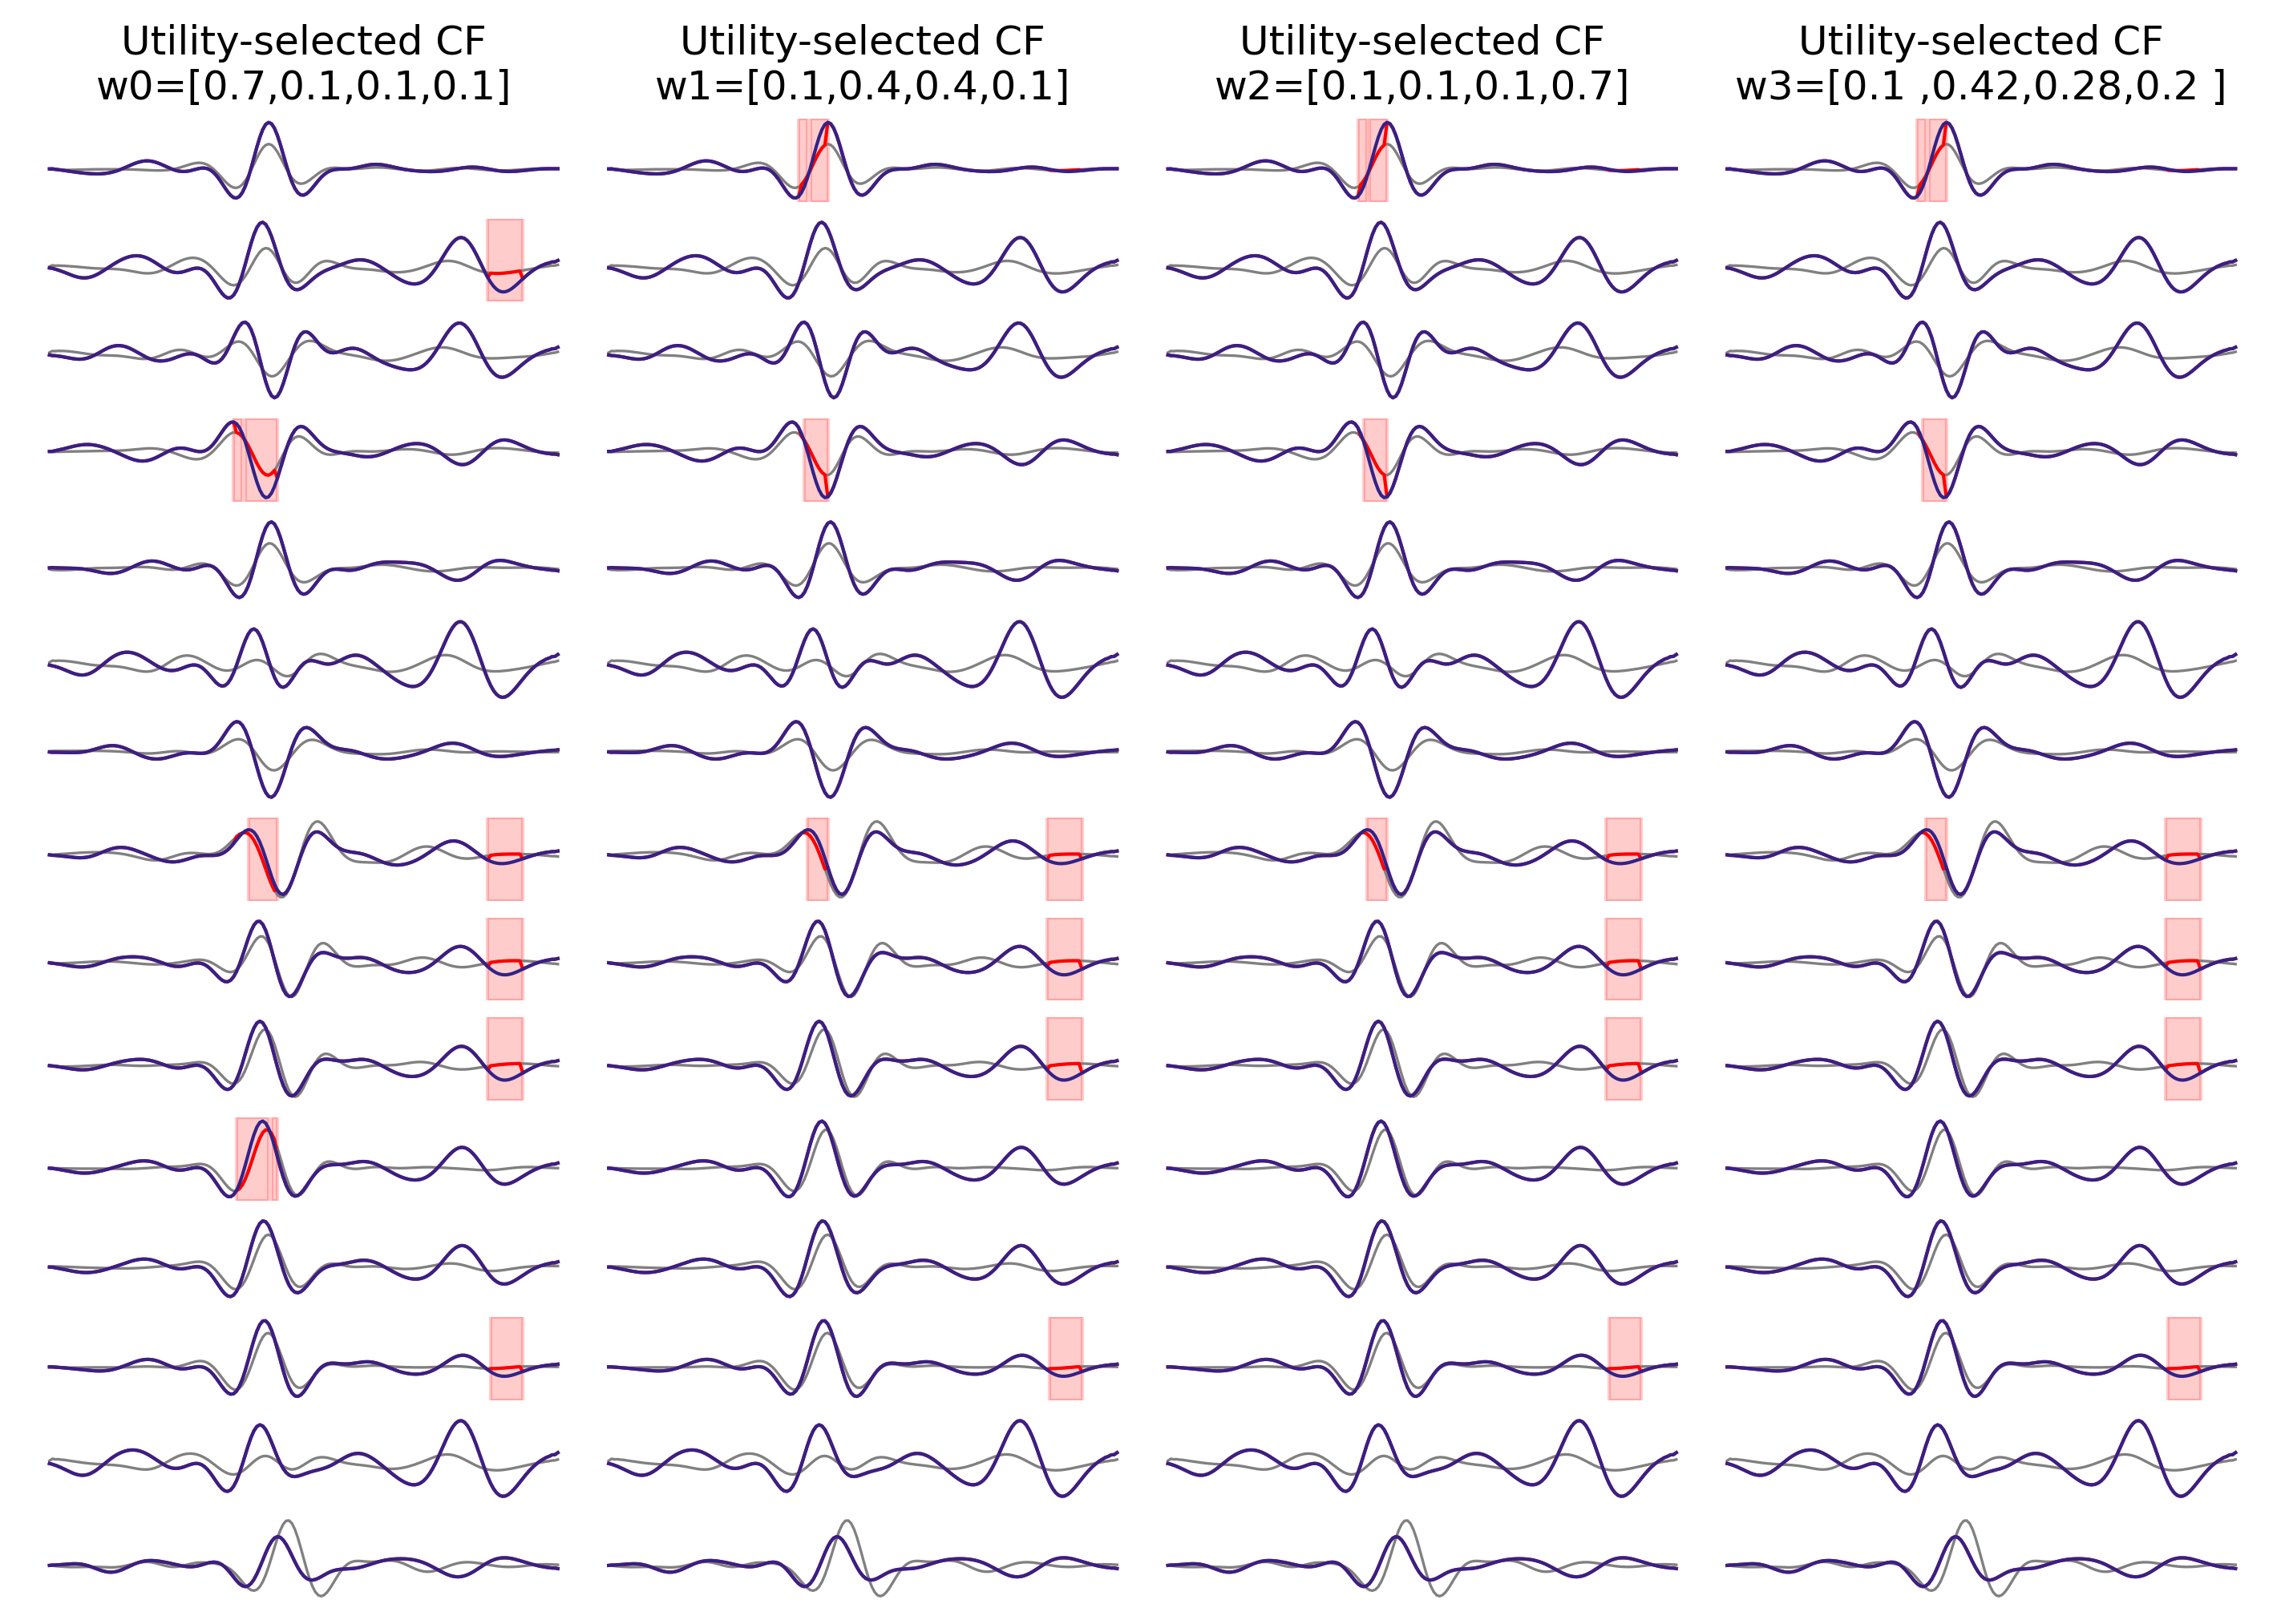

In [13]:
# Norm -> MI: 0, 2, 10, 14, 15, 18, 21, 25
# MI -> Norm: 36, 40, 51(mistake), 53, 55, 58, 67, 68, 69 (amplitude), 70(amp), 71! (twave increase), 74(MISTAKE), 81, 83, 84, 87, 89, 90, 91, 94!
instance = 81

utility_selection_df, utility_selected_cfs, utility_selected_candidate_ids = select_best_cfs_for_utility_weights(
    instance,
    UTILITY_WEIGHT_LIST,
)
print(f'Instance position {instance}, original ii={int(subset_idx[instance])}')
display(utility_selection_df)

utility_x_orig = X_test[instance]
utility_possible_nuns = {'gknn': nuns[instance]} if 'nuns' in globals() and nuns is not None else None
print(
    f'Sample {int(subset_idx[instance])}: true class {y_test[instance]}, '
    f'x_orig predicted {y_pred_test[instance]}'
)
plot_comp_cfs_multispace_style(
    utility_x_orig,
    utility_possible_nuns,
    utility_selected_cfs,
    store=False,
    title_prefix='Utility-selected CF',
)


# Study about ecg changes

In [14]:
# Cell 1 — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon

# Shape helpers used by the ECG morphology cells.
def ensure_time_channel(x):
    arr = np.asarray(x)
    arr = np.squeeze(arr)
    if arr.ndim == 1:
        return arr.reshape(-1, 1)
    if arr.ndim == 2:
        # Preserve all channels. If one axis is clearly the channel axis, put time first.
        if arr.shape[0] < arr.shape[1] and arr.shape[0] <= 32:
            return arr.T
        return arr
    if arr.ndim == 3 and arr.shape[0] == 1:
        return ensure_time_channel(arr[0])
    raise ValueError(f"Expected signal convertible to (time, channels), got shape {arr.shape}")


def ensure_batch_time_channel(x):
    arr = np.asarray(x)
    if arr.ndim == 2:
        return ensure_time_channel(arr)[None, ...]
    if arr.ndim == 3:
        converted = [ensure_time_channel(arr[i]) for i in range(arr.shape[0])]
        return np.stack(converted, axis=0)
    if arr.ndim == 4 and arr.shape[1] == 1:
        return ensure_batch_time_channel(arr[:, 0])
    raise ValueError(f"Expected batch convertible to (n, time, channels), got shape {arr.shape}")


In [37]:
# Cell 4 — NeuroKit reference delineation from original and NUN, propagated to all channels

ECG_DELINEATION_CHANNEL_IDX = 1  # Lead II in the current channel convention.
ECG_SAMPLING_RATE = 100          # Change if your preprocessed PTB-XL sampling rate differs.
USE_NEUROKIT_DELINEATION = True
REFERENCE_WINDOW_MODE = "union"  # "union", "orig", "nun", or "intersection".
NEUROKIT_METHOD = "dwt"

try:
    import neurokit2 as nk
    NEUROKIT_AVAILABLE = True
    print(f"NeuroKit2 available: {nk.__version__}")
except Exception as exc:
    nk = None
    NEUROKIT_AVAILABLE = False
    print(f"NeuroKit2 not available in this kernel. Falling back to centered windows. Reason: {exc}")


def clip_window(window, n_time):
    if window is None:
        return None
    a, b = window
    if a is None or b is None or pd.isna(a) or pd.isna(b):
        return None
    a = max(0, int(round(a)))
    b = min(n_time, int(round(b)))
    return (a, b) if a < b else None


def get_centered_windows(n_time, r_index=None):
    """Fallback windows used only when NeuroKit delineation is unavailable or fails."""
    if r_index is None:
        r_index = n_time // 2
    raw = {
        "baseline": (r_index - 65, r_index - 45),
        "p":        (r_index - 55, r_index - 32),
        "q":        (r_index - 30, r_index - 8),
        "r":        (r_index - 6,  r_index + 6),
        "st":       (r_index + 12, r_index + 35),
        "t":        (r_index + 35, r_index + 70),
    }
    return {name: clip_window(window, n_time) for name, window in raw.items()}


def get_global_windows(n_time, r_index=None):
    """Backward-compatible fallback window function."""
    return get_centered_windows(n_time, r_index=r_index)


def nearest_valid_index(values, target):
    if values is None:
        return None
    arr = np.asarray(values, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return None
    return int(arr[np.argmin(np.abs(arr - target))])


def neurokit_reference_windows_1d(signal, sampling_rate=ECG_SAMPLING_RATE, r_index=None):
    """
    Delineate one reference ECG channel with NeuroKit and convert landmarks to windows.
    Returns (windows, metadata). Raises if delineation fails.
    """
    if not (USE_NEUROKIT_DELINEATION and NEUROKIT_AVAILABLE):
        raise RuntimeError("NeuroKit delineation is disabled or unavailable")

    signal = np.asarray(signal, dtype=float).reshape(-1)
    n_time = len(signal)
    if r_index is None:
        r_index = n_time // 2

    cleaned = nk.ecg_clean(signal, sampling_rate=sampling_rate, method="neurokit")
    _, peaks_info = nk.ecg_peaks(cleaned, sampling_rate=sampling_rate)
    rpeaks = np.asarray(peaks_info.get("ECG_R_Peaks", []), dtype=int)
    if rpeaks.size == 0:
        rpeaks = np.asarray([r_index], dtype=int)
    rpeak = int(rpeaks[np.argmin(np.abs(rpeaks - r_index))])

    _, waves = nk.ecg_delineate(
        cleaned,
        rpeaks=np.asarray([rpeak], dtype=int),
        sampling_rate=sampling_rate,
        method=NEUROKIT_METHOD,
        show=False,
    )

    landmark_keys = {
        "p_on": "ECG_P_Onsets",
        "p_peak": "ECG_P_Peaks",
        "p_off": "ECG_P_Offsets",
        "q_peak": "ECG_Q_Peaks",
        "r_on": "ECG_R_Onsets",
        "r_off": "ECG_R_Offsets",
        "s_peak": "ECG_S_Peaks",
        "t_on": "ECG_T_Onsets",
        "t_peak": "ECG_T_Peaks",
        "t_off": "ECG_T_Offsets",
    }
    lm = {name: nearest_valid_index(waves.get(key), rpeak) for name, key in landmark_keys.items()}
    lm["r_peak"] = rpeak

    # Prefer delineated intervals. When a boundary is missing, use a small local fallback around peaks.
    windows = {
        "baseline": clip_window((
            (lm["p_on"] - int(0.20 * sampling_rate)) if lm.get("p_on") is not None else rpeak - int(0.65 * sampling_rate),
            (lm["p_on"] - int(0.04 * sampling_rate)) if lm.get("p_on") is not None else rpeak - int(0.45 * sampling_rate),
        ), n_time),
        "p": clip_window((lm.get("p_on"), lm.get("p_off")), n_time),
        "q": clip_window((
            lm.get("r_on") if lm.get("r_on") is not None else (lm.get("q_peak") - int(0.04 * sampling_rate) if lm.get("q_peak") is not None else rpeak - int(0.08 * sampling_rate)),
            lm.get("r_peak") if lm.get("r_peak") is not None else rpeak,
        ), n_time),
        "r": clip_window((
            lm.get("r_on") if lm.get("r_on") is not None else rpeak - int(0.04 * sampling_rate),
            lm.get("r_off") if lm.get("r_off") is not None else rpeak + int(0.04 * sampling_rate),
        ), n_time),
        "st": clip_window((
            lm.get("r_off") if lm.get("r_off") is not None else rpeak + int(0.06 * sampling_rate),
            lm.get("t_on") if lm.get("t_on") is not None else rpeak + int(0.35 * sampling_rate),
        ), n_time),
        "t": clip_window((
            lm.get("t_on") if lm.get("t_on") is not None else (lm.get("t_peak") - int(0.12 * sampling_rate) if lm.get("t_peak") is not None else rpeak + int(0.35 * sampling_rate)),
            lm.get("t_off") if lm.get("t_off") is not None else (lm.get("t_peak") + int(0.16 * sampling_rate) if lm.get("t_peak") is not None else rpeak + int(0.70 * sampling_rate)),
        ), n_time),
    }
    return windows, {"source": "neurokit", "r_index": rpeak, **lm}


def combine_two_windows(w1, w2, n_time, mode=REFERENCE_WINDOW_MODE):
    w1 = clip_window(w1, n_time)
    w2 = clip_window(w2, n_time)
    if mode == "orig":
        return w1
    if mode == "nun":
        return w2
    if w1 is None:
        return w2
    if w2 is None:
        return w1
    if mode == "intersection":
        return clip_window((max(w1[0], w2[0]), min(w1[1], w2[1])), n_time)
    return clip_window((min(w1[0], w2[0]), max(w1[1], w2[1])), n_time)


def reference_windows_from_orig_nun(x_orig, x_nun=None, r_index=None, channel_idx=ECG_DELINEATION_CHANNEL_IDX):
    """
    Delineate only one reference channel from x_orig and x_nun, then combine those time regions.
    The resulting windows are propagated to all channels by downstream analysis.
    """
    x_orig = ensure_time_channel(x_orig)
    n_time, n_channels = x_orig.shape
    if channel_idx >= n_channels:
        raise ValueError(f"ECG_DELINEATION_CHANNEL_IDX={channel_idx}, but only {n_channels} channels are available")
    if r_index is None:
        r_index = n_time // 2

    fallback = get_centered_windows(n_time, r_index=r_index)
    meta = {
        "delineation_channel": channel_idx,
        "reference_window_mode": REFERENCE_WINDOW_MODE,
        "orig_source": "fallback_centered",
        "nun_source": "missing",
        "combined_source": "fallback_centered",
        "orig_r_index": r_index,
        "nun_r_index": None,
    }

    try:
        orig_windows, orig_meta = neurokit_reference_windows_1d(x_orig[:, channel_idx], r_index=r_index)
        meta.update({"orig_source": orig_meta.get("source"), "orig_r_index": orig_meta.get("r_index")})
    except Exception as exc:
        print("ERRORRRRR!")
        orig_windows = fallback
        meta["orig_error"] = repr(exc)

    if x_nun is not None:
        x_nun = ensure_time_channel(x_nun)
        try:
            nun_windows, nun_meta = neurokit_reference_windows_1d(x_nun[:, channel_idx], r_index=meta.get("orig_r_index") or r_index)
            meta.update({"nun_source": nun_meta.get("source"), "nun_r_index": nun_meta.get("r_index")})
        except Exception as exc:
            nun_windows = fallback
            meta.update({"nun_source": "fallback_centered", "nun_error": repr(exc)})
    else:
        nun_windows = orig_windows

    combined = {
        name: combine_two_windows(orig_windows.get(name), nun_windows.get(name), n_time, mode=REFERENCE_WINDOW_MODE)
        for name in sorted(set(orig_windows) | set(nun_windows))
    }
    if meta["orig_source"] == "neurokit" or meta["nun_source"] == "neurokit":
        meta["combined_source"] = f"{REFERENCE_WINDOW_MODE}_orig_nun_reference"
    return combined, meta


NeuroKit2 available: 0.2.9


In [38]:
# Cell 5 — Window utilities

def safe_segment(signal, window):
    """
    Extracts a segment from a 1D signal.
    """
    if window is None:
        return np.array([], dtype=float)

    a, b = window
    return np.asarray(signal[a:b], dtype=float)


def safe_median(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    return np.nanmedian(x)


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    return np.nanmean(x)


def safe_min(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    return np.nanmin(x)


def safe_max(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan
    return np.nanmax(x)

In [39]:
# Cell 6 — Morphology metrics for one 1D channel

def morphology_features_1d(signal, windows=None, r_index=None):
    """
    Computes morphology features for one channel using reference windows.

    Windows are expected to come from Lead-II delineation of x_orig and NUN,
    then propagated to all channels. If not supplied, centered fallback windows are used.
    """
    signal = np.asarray(signal, dtype=float)

    if r_index is None:
        r_index = len(signal) // 2
    if windows is None:
        windows = get_centered_windows(len(signal), r_index=r_index)

    baseline_seg = safe_segment(signal, windows.get("baseline"))
    q_seg = safe_segment(signal, windows.get("q"))
    st_seg = safe_segment(signal, windows.get("st"))
    t_seg = safe_segment(signal, windows.get("t"))

    baseline = safe_median(baseline_seg)

    q_centered = q_seg - baseline
    st_centered = st_seg - baseline
    t_centered = t_seg - baseline

    q_amp = safe_min(q_centered)
    q_extreme_abs = safe_max(np.abs(q_centered))

    st_level = safe_mean(st_centered)
    st_abs = safe_mean(np.abs(st_centered))

    st_q_contrast = st_level - q_amp

    t_peak_abs = safe_max(np.abs(t_centered))
    t_area_abs = safe_mean(np.abs(t_centered))

    return {
        "baseline": baseline,
        "q_amp": q_amp,
        "q_extreme_abs": q_extreme_abs,
        "st_level": st_level,
        "st_abs": st_abs,
        "st_q_contrast": st_q_contrast,
        "t_peak_abs": t_peak_abs,
        "t_area_abs": t_area_abs,
    }


In [40]:
# Cell 7 — Analyze one original/counterfactual pair globally across channels

def analyze_cf_pair_global(x_orig, x_cf, x_nun=None, instance_id=None, r_index=None):
    """
    Analyzes one original/counterfactual pair.

    Delineation is performed only on ECG_DELINEATION_CHANNEL_IDX from x_orig and x_nun.
    The resulting reference windows are propagated to every channel.
    """
    x_orig = ensure_time_channel(x_orig)
    x_cf = ensure_time_channel(x_cf)
    x_nun = ensure_time_channel(x_nun) if x_nun is not None else None

    if x_orig.shape != x_cf.shape:
        raise ValueError(f"x_orig and x_cf shapes differ: {x_orig.shape} vs {x_cf.shape}")

    n_time, n_channels = x_orig.shape
    if r_index is None:
        r_index = n_time // 2

    windows, delineation_meta = reference_windows_from_orig_nun(
        x_orig,
        x_nun=x_nun,
        r_index=r_index,
        channel_idx=ECG_DELINEATION_CHANNEL_IDX,
    )

    rows = []
    for ch in range(n_channels):
        f_orig = morphology_features_1d(x_orig[:, ch], windows=windows, r_index=r_index)
        f_cf = morphology_features_1d(x_cf[:, ch], windows=windows, r_index=r_index)

        row = {
            "instance_id": instance_id,
            "channel": ch,
            "r_index": delineation_meta.get("orig_r_index", r_index),
            "delineation_channel": delineation_meta.get("delineation_channel"),
            "delineation_source": delineation_meta.get("combined_source"),
            "orig_delineation_source": delineation_meta.get("orig_source"),
            "nun_delineation_source": delineation_meta.get("nun_source"),
            "reference_window_mode": delineation_meta.get("reference_window_mode"),
        }
        for region_name, window in windows.items():
            if window is not None:
                row[f"{region_name}_window_start"] = window[0]
                row[f"{region_name}_window_end"] = window[1]

        for key in f_orig:
            row[f"{key}_orig"] = f_orig[key]
            row[f"{key}_cf"] = f_cf[key]
            row[f"delta_{key}"] = f_cf[key] - f_orig[key]
        rows.append(row)

    return rows


In [41]:
# Cell 8 — Analyze all pairs

def analyze_all_pairs_global(x_orig_all, x_cf_all, x_nun_all=None, instance_ids=None, r_index=None):
    """
    Runs global morphology analysis for all original/counterfactual pairs.

    If x_nun_all is supplied, Lead-II delineation is derived from each original and NUN pair.
    """
    x_orig_all = ensure_batch_time_channel(x_orig_all)
    x_cf_all = ensure_batch_time_channel(x_cf_all)
    if x_nun_all is not None:
        x_nun_all = ensure_batch_time_channel(x_nun_all)

    if x_orig_all.shape != x_cf_all.shape:
        raise ValueError(f"Batch shapes differ: {x_orig_all.shape} vs {x_cf_all.shape}")
    if x_nun_all is not None and x_nun_all.shape != x_orig_all.shape:
        raise ValueError(f"NUN shape differs: {x_nun_all.shape} vs {x_orig_all.shape}")

    n_instances = x_orig_all.shape[0]
    if instance_ids is None:
        instance_ids = list(range(n_instances))

    all_rows = []
    for i in range(n_instances):
        rows = analyze_cf_pair_global(
            x_orig=x_orig_all[i],
            x_cf=x_cf_all[i],
            x_nun=x_nun_all[i] if x_nun_all is not None else None,
            instance_id=instance_ids[i],
            r_index=r_index,
        )
        all_rows.extend(rows)

    return pd.DataFrame(all_rows)


In [42]:
# Cell 9 — Global summary with medians, IQR, percentages, Wilcoxon tests

def summarize_global_morphology(df):
    """
    Summarizes global morphology changes across all instance-channel pairs.

    Expected directions for NORM -> MI:
    - delta_q_amp < 0: Q-window becomes lower/deeper
    - delta_q_extreme_abs > 0: Q-window becomes more pronounced, polarity-invariant
    - delta_st_level > 0: ST-window level increases
    - delta_st_abs > 0: ST-window deviation increases, polarity-invariant
    - delta_st_q_contrast > 0: ST appears higher relative to Q minimum
    - delta_t_peak_abs < 0: T peak amplitude flattens
    - delta_t_area_abs < 0: T area/amplitude flattens
    """
    metric_specs = {
        "delta_q_amp": "less",
        "delta_q_extreme_abs": "greater",
        "delta_st_level": "greater",
        "delta_st_abs": "greater",
        "delta_st_q_contrast": "greater",
        "delta_t_peak_abs": "less",
        "delta_t_area_abs": "less",
    }

    rows = []

    for metric, direction in metric_specs.items():
        if metric not in df.columns:
            continue

        vals = df[metric].replace([np.inf, -np.inf], np.nan).dropna().values

        if len(vals) == 0:
            continue

        if direction == "less":
            pct_expected = np.mean(vals < 0) * 100
            alternative = "less"
        else:
            pct_expected = np.mean(vals > 0) * 100
            alternative = "greater"

        try:
            if len(vals) > 0 and np.any(vals != 0):
                stat, p_value = wilcoxon(vals, alternative=alternative)
            else:
                stat, p_value = np.nan, np.nan
        except Exception:
            stat, p_value = np.nan, np.nan

        rows.append({
            "metric": metric,
            "expected_direction": direction,
            "n_instance_channel_pairs": len(vals),
            "median_delta": np.median(vals),
            "q1": np.percentile(vals, 25),
            "q3": np.percentile(vals, 75),
            "mean_delta": np.mean(vals),
            "std_delta": np.std(vals),
            "pct_in_expected_direction": pct_expected,
            "wilcoxon_stat": stat,
            "wilcoxon_p": p_value,
        })

    return pd.DataFrame(rows)


# Run after morphology_df:
# global_summary = summarize_global_morphology(morphology_df)
# global_summary

In [43]:
# Cell 10 — Per-channel summary, still no channel names assumed

def summarize_by_channel(df):
    """
    Summarizes morphology changes per generic channel index.
    """
    rows = []

    for ch, g in df.groupby("channel"):
        row = {"channel": ch, "n": len(g)}

        for metric in [
            "delta_q_amp",
            "delta_q_extreme_abs",
            "delta_st_level",
            "delta_st_abs",
            "delta_st_q_contrast",
            "delta_t_peak_abs",
            "delta_t_area_abs",
        ]:
            if metric not in g.columns:
                continue

            vals = g[metric].replace([np.inf, -np.inf], np.nan).dropna().values
            if len(vals) == 0:
                continue

            row[f"{metric}_median"] = np.median(vals)
            row[f"{metric}_q1"] = np.percentile(vals, 25)
            row[f"{metric}_q3"] = np.percentile(vals, 75)

            if metric in ["delta_q_amp", "delta_t_peak_abs", "delta_t_area_abs"]:
                row[f"{metric}_pct_expected"] = np.mean(vals < 0) * 100
            else:
                row[f"{metric}_pct_expected"] = np.mean(vals > 0) * 100

        rows.append(row)

    return pd.DataFrame(rows)


# Run after morphology_df:
# channel_summary = summarize_by_channel(morphology_df)
# channel_summary

In [44]:
# Cell 11 — Mask overlap with reference-delineated regions

def infer_mask_from_difference(x_orig, x_cf, tolerance=1e-6):
    """
    Infers changed mask from absolute difference.
    Returns boolean mask with shape (time, channels).
    """
    x_orig = ensure_time_channel(x_orig)
    x_cf = ensure_time_channel(x_cf)

    if x_orig.shape != x_cf.shape:
        raise ValueError(f"x_orig and x_cf shapes differ: {x_orig.shape} vs {x_cf.shape}")

    return np.abs(x_cf - x_orig) > tolerance


def mask_overlap_one(mask, windows=None, r_index=None):
    """
    Computes percentage of changed points falling in each reference-delineated region.
    The same time windows are propagated across all channels.
    """
    mask = ensure_time_channel(mask).astype(bool)
    n_time, n_channels = mask.shape

    if r_index is None:
        r_index = n_time // 2
    if windows is None:
        windows = get_centered_windows(n_time, r_index=r_index)

    total_changed = int(mask.sum())
    out = {"total_changed_points": total_changed}
    covered = np.zeros_like(mask, dtype=bool)

    for name, window in windows.items():
        if window is None:
            out[f"{name}_changed_points"] = 0
            out[f"{name}_changed_pct"] = 0.0
            continue

        a, b = window
        region_mask = np.zeros_like(mask, dtype=bool)
        region_mask[a:b, :] = True

        count = int(np.logical_and(mask, region_mask).sum())
        out[f"{name}_changed_points"] = count
        out[f"{name}_changed_pct"] = 100 * count / total_changed if total_changed > 0 else 0.0
        covered |= region_mask

    other_count = int(np.logical_and(mask, ~covered).sum())
    out["other_changed_points"] = other_count
    out["other_changed_pct"] = 100 * other_count / total_changed if total_changed > 0 else 0.0
    return out


def mask_overlap_all(x_orig_all, x_cf_all, x_nun_all=None, masks_all=None, tolerance=1e-6, r_index=None):
    """
    Computes mask-region overlap for all instances.

    Regions are derived from Lead-II delineation of x_orig and x_nun when available.
    If masks_all is None, masks are inferred from x_orig != x_cf.
    """
    x_orig_all = ensure_batch_time_channel(x_orig_all)
    x_cf_all = ensure_batch_time_channel(x_cf_all)
    if x_nun_all is not None:
        x_nun_all = ensure_batch_time_channel(x_nun_all)
    if masks_all is not None:
        masks_all = ensure_batch_time_channel(masks_all)

    rows = []
    for i in range(x_orig_all.shape[0]):
        if masks_all is not None:
            mask = masks_all[i]
        else:
            mask = infer_mask_from_difference(x_orig_all[i], x_cf_all[i], tolerance=tolerance)

        windows, delineation_meta = reference_windows_from_orig_nun(
            x_orig_all[i],
            x_nun=x_nun_all[i] if x_nun_all is not None else None,
            r_index=r_index,
            channel_idx=ECG_DELINEATION_CHANNEL_IDX,
        )
        row = mask_overlap_one(mask, windows=windows, r_index=delineation_meta.get("orig_r_index", r_index))
        row["instance_id"] = i
        row["delineation_channel"] = delineation_meta.get("delineation_channel")
        row["delineation_source"] = delineation_meta.get("combined_source")
        row["orig_delineation_source"] = delineation_meta.get("orig_source")
        row["nun_delineation_source"] = delineation_meta.get("nun_source")
        row["reference_window_mode"] = delineation_meta.get("reference_window_mode")
        rows.append(row)

    return pd.DataFrame(rows)


In [45]:
# Cell 12 — Summarize mask overlap globally

def summarize_mask_overlap(mask_overlap_df):
    """
    Summarizes mask overlap percentages across instances.
    """
    pct_cols = [c for c in mask_overlap_df.columns if c.endswith("_changed_pct")]

    rows = []
    for col in pct_cols:
        vals = mask_overlap_df[col].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(vals) == 0:
            continue

        rows.append({
            "region": col.replace("_changed_pct", ""),
            "median_changed_pct": np.median(vals),
            "q1": np.percentile(vals, 25),
            "q3": np.percentile(vals, 75),
            "mean_changed_pct": np.mean(vals),
            "std_changed_pct": np.std(vals),
        })

    return pd.DataFrame(rows).sort_values("median_changed_pct", ascending=False)


# Run after mask_overlap_df:
# mask_overlap_summary = summarize_mask_overlap(mask_overlap_df)
# mask_overlap_summary

In [46]:
# Cell 13 — Plot global metric distributions

def plot_global_delta_distributions(df):
    """
    Boxplot of global morphology delta distributions.
    """
    metrics = [
        "delta_q_amp",
        "delta_q_extreme_abs",
        "delta_st_level",
        "delta_st_abs",
        "delta_st_q_contrast",
        "delta_t_peak_abs",
        "delta_t_area_abs",
    ]

    available = [m for m in metrics if m in df.columns]

    data = [
        df[m].replace([np.inf, -np.inf], np.nan).dropna().values
        for m in available
    ]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(data, showfliers=False)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title("Global morphology changes: counterfactual minus original")
    ax.set_ylabel("Delta value")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# Run:
# plot_global_delta_distributions(morphology_df)

In [47]:
# Cell 14 — Plot per-channel median changes

def plot_per_channel_medians(df, metric):
    """
    Barplot of median delta per generic channel.
    """
    if metric not in df.columns:
        raise ValueError(f"Metric not found: {metric}")

    med = (
        df.groupby("channel")[metric]
        .median()
        .reset_index()
        .sort_values("channel")
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(med["channel"].astype(str), med[metric])
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"Median {metric} by channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel(f"Median {metric}")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


# Examples:
# plot_per_channel_medians(morphology_df, "delta_q_amp")
# plot_per_channel_medians(morphology_df, "delta_st_q_contrast")
# plot_per_channel_medians(morphology_df, "delta_t_peak_abs")

In [48]:
# Cell 15 — Plot mask overlap summary

def plot_mask_overlap_summary(mask_overlap_summary):
    """
    Barplot of median changed percentage by R-centered region.
    """
    plot_df = mask_overlap_summary.copy()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(plot_df["region"], plot_df["median_changed_pct"])
    ax.set_title("Median percentage of changed points by R-centered region")
    ax.set_ylabel("Median changed points (%)")
    ax.set_xlabel("Region")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


# Run:
# plot_mask_overlap_summary(mask_overlap_summary)

In [49]:
# Cell 16 — Plot average original vs average counterfactual globally

def plot_average_waveforms(x_orig_all, x_cf_all, channels=None, r_index=None):
    """
    Plots average original and average counterfactual waveform.
    Window shading uses fallback centered windows because an averaged waveform has no NUN reference.
    """
    x_orig_all = ensure_batch_time_channel(x_orig_all)
    x_cf_all = ensure_batch_time_channel(x_cf_all)

    n_instances, n_time, n_channels = x_orig_all.shape
    if r_index is None:
        r_index = n_time // 2

    if channels is None:
        orig_mean = x_orig_all.mean(axis=(0, 2))
        cf_mean = x_cf_all.mean(axis=(0, 2))
        title_suffix = "averaged across all channels"
    else:
        orig_mean = x_orig_all[:, :, channels].mean(axis=(0, 2))
        cf_mean = x_cf_all[:, :, channels].mean(axis=(0, 2))
        title_suffix = f"averaged across channels {channels}"

    windows = get_centered_windows(n_time, r_index=r_index)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(orig_mean, label="Original mean", linewidth=2)
    ax.plot(cf_mean, label="Counterfactual mean", linewidth=2)
    ax.axvline(r_index, linestyle="--", linewidth=1, label="center")

    for name, window in windows.items():
        if window is None:
            continue
        a, b = window
        ax.axvspan(a, b, alpha=0.10, label=name)

    ax.set_title(f"Average original vs counterfactual waveform ({title_suffix})")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), ncols=2)

    plt.tight_layout()
    plt.show()


In [50]:
# Cell 17 — Plot one example with reference windows

def plot_one_pair_with_windows(x_orig, x_cf, x_nun=None, channel=0, r_index=None, title=None):
    """
    Plots one original/counterfactual pair for one channel.
    Windows are derived from Lead-II delineation of x_orig and x_nun, then shown on this channel.
    """
    x_orig = ensure_time_channel(x_orig)
    x_cf = ensure_time_channel(x_cf)
    x_nun = ensure_time_channel(x_nun) if x_nun is not None else None

    n_time, n_channels = x_orig.shape
    if r_index is None:
        r_index = n_time // 2
    if channel >= n_channels:
        raise ValueError(f"channel={channel} but only {n_channels} channels available")

    windows, delineation_meta = reference_windows_from_orig_nun(x_orig, x_nun=x_nun, r_index=r_index)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(x_orig[:, channel], label="Original", linewidth=2)
    ax.plot(x_cf[:, channel], label="Counterfactual", linewidth=2)
    if x_nun is not None:
        ax.plot(x_nun[:, channel], label="NUN", linewidth=1.2, linestyle="--")
    ax.axvline(delineation_meta.get("orig_r_index", r_index), linestyle="--", linewidth=1, label="reference R")

    for name, window in windows.items():
        if window is None:
            continue
        a, b = window
        ax.axvspan(a, b, alpha=0.10, label=name)

    if title is None:
        title = f"Original vs counterfactual, channel {channel}"
    ax.set_title(title + f" ({delineation_meta.get('combined_source')})")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), ncols=2)

    plt.tight_layout()
    plt.show()


In [51]:
# Cell 19 — Generate manuscript-friendly result sentences

def format_p(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return "< 1e-4"
    return f"{p:.4f}"


def make_result_sentences(global_summary):
    """
    Produces rough manuscript-friendly sentences from the global summary.
    """
    label_map = {
        "delta_q_amp": "Q-window amplitude decreased",
        "delta_q_extreme_abs": "Q-window absolute deviation increased",
        "delta_st_level": "ST-window level increased",
        "delta_st_abs": "ST-window absolute deviation increased",
        "delta_st_q_contrast": "ST-Q contrast increased",
        "delta_t_peak_abs": "T-window peak absolute amplitude decreased",
        "delta_t_area_abs": "T-window mean absolute amplitude decreased",
    }

    for _, row in global_summary.iterrows():
        metric = row["metric"]
        label = label_map.get(metric, metric)

        sentence = (
            f"{label}: median delta = {row['median_delta']:.4g} "
            f"[IQR {row['q1']:.4g}, {row['q3']:.4g}], "
            f"{row['pct_in_expected_direction']:.1f}% in the expected direction, "
            f"one-sided Wilcoxon p = {format_p(row['wilcoxon_p'])}."
        )
        print(sentence)


# Run:
# make_result_sentences(global_summary)

In [52]:
# Cell 20 — Suggested safe interpretation template

interpretation_template = """
Interpretation template:

Across all channels and NORM-to-MI counterfactuals, we quantified changes using fixed R-centered waveform windows.
The analysis did not assume channel names or clinical lead ordering.

The main quantities were:
1. Q-window amplitude: lower values indicate deeper early QRS/Q-like deflections.
2. ST-window level: higher values indicate increased post-QRS level relative to the local pre-QRS baseline.
3. ST-Q contrast: higher values indicate that the ST region appears elevated relative to the Q-window minimum.
4. T-window amplitude: lower absolute amplitude indicates flatter repolarization morphology.

A clinically cautious conclusion can be:
"The counterfactuals tended to introduce localized morphology changes around QRS/ST-T windows.
In particular, the observed changes in Q-window depth, ST-Q contrast, and T-window amplitude suggest that the classifier's NORM-to-MI decision boundary can be crossed through waveform modifications that are inspectable in ECG morphology.
These results should be interpreted as model-behavior evidence, not as clinical proof of infarction mechanisms."
"""

print(interpretation_template)


Interpretation template:

Across all channels and NORM-to-MI counterfactuals, we quantified changes using fixed R-centered waveform windows.
The analysis did not assume channel names or clinical lead ordering.

The main quantities were:
1. Q-window amplitude: lower values indicate deeper early QRS/Q-like deflections.
2. ST-window level: higher values indicate increased post-QRS level relative to the local pre-QRS baseline.
3. ST-Q contrast: higher values indicate that the ST region appears elevated relative to the Q-window minimum.
4. T-window amplitude: lower absolute amplitude indicates flatter repolarization morphology.

A clinically cautious conclusion can be:
"The counterfactuals tended to introduce localized morphology changes around QRS/ST-T windows.
In particular, the observed changes in Q-window depth, ST-Q contrast, and T-window amplitude suggest that the classifier's NORM-to-MI decision boundary can be crossed through waveform modifications that are inspectable in ECG morph

## 7. Adapter for Global NORM->MI Morphology Analysis

These additive cells inspect the currently loaded counterfactual explanation objects and build standardized arrays for the global morphology functions. They do not change the analysis logic.

In [53]:
# --- Morphology adapter helper functions ---
import warnings
from collections.abc import Mapping

FORCE_TRANSPOSE = False
MASK_TOLERANCE = 1e-6
APPLY_NORM_MI_FILTER = True
STRICT_NORM_MI_FILTER = False
CLASS_NAMES = {0: "NORM", 1: "MI"}  # Example: {0: "NORM", 1: "MI"} or ["NORM", "MI"]
NORM_LABEL = "NORM"
MI_LABEL = "MI"

ORIG_KEYS = ["x_orig", "x_original", "original", "orig", "x", "query", "instance", "test_instance"]
CF_KEYS = ["x_cf", "cf", "counterfactual", "counterfactuals", "cfs", "x_counterfactual"]
NUN_KEYS = ["x_nun", "nun", "nearest_unlike_neighbor", "nearest_unlike", "x_target"]
MASK_KEYS = ["mask", "change_mask", "orig_change_mask", "cf_mask", "m"]
PARETO_KEYS = ["pareto", "pareto_front", "front", "population", "solutions", "candidates", "explanations"]
Y_TRUE_KEYS = ["y_true", "true_label", "label"]
PRED_ORIG_KEYS = ["predicted_orig", "pred_orig", "y_pred_orig", "original_prediction"]
PRED_CF_KEYS = ["predicted_cf", "pred_cf", "y_pred_cf", "cf_prediction"]
TARGET_KEYS = ["target_class", "desired_class", "nun_class", "y_target"]
VALID_KEYS = ["validity", "valid", "is_valid"]
BEST_KEYS = ["best_cf", "best_counterfactual", "selected_cf", "cf"]
BEST_INDEX_KEYS = ["best cf index", "best_cf_index", "best_candidate", "selected_candidate", "selected_cf_index"]

METRIC_ALIASES = {
    "adv": ["target_prob", "target_probability", "desired_class_prob", "prob", "prediction_prob", "proba", "adv", "adversarial"],
    "sparsity": ["sparsity", "nchanges", "num_changes", "number_changes", "L0"],
    "subseq": ["subsequences", "subsequences %", "num_subsequences", "nos", "NoS", "contiguity"],
    "plausibility": ["plausibility", "outlier_score", "increase_outlier_score", "ios", "IoS", "AE_IOS", "AE_OS", "LOF_IOS", "IF_IOS"],
}
UTILITY_WEIGHTS = {"adv": 0.1, "sparsity": 0.3, "subseq": 0.4, "plausibility": 0.2}
UTILITY_DIRECTIONS = {"adv": "max", "sparsity": "min", "subseq": "min", "plausibility": "min"}


def is_array_like(value):
    if value is None or isinstance(value, (str, bytes, Mapping)):
        return False
    try:
        arr = np.asarray(value)
        return arr.size > 0 and arr.dtype != object or hasattr(value, "shape")
    except Exception:
        return False


def shape_of(value):
    try:
        return tuple(np.asarray(value).shape)
    except Exception:
        return None


def summarize_object(value, max_keys=20):
    if isinstance(value, Mapping):
        keys = list(value.keys())[:max_keys]
        return {"type": type(value).__name__, "keys": keys}
    if isinstance(value, (list, tuple)):
        first = value[0] if value else None
        return {"type": type(value).__name__, "len": len(value), "first": summarize_object(first, max_keys=8) if first is not None else None}
    return {"type": type(value).__name__, "shape": shape_of(value)}


def find_value(mapping, keys, default=None):
    if not isinstance(mapping, Mapping):
        return default
    lowered = {str(k).lower(): k for k in mapping.keys()}
    for key in keys:
        if key in mapping:
            return mapping[key]
        real_key = lowered.get(str(key).lower())
        if real_key is not None:
            return mapping[real_key]
    return default


def scalarize(value):
    if value is None:
        return None
    if isinstance(value, np.generic):
        return value.item()
    arr = None
    try:
        arr = np.asarray(value)
    except Exception:
        pass
    if arr is not None and arr.size == 1 and arr.dtype != object:
        return arr.reshape(-1)[0].item()
    if arr is not None and arr.ndim == 1 and arr.size <= 20 and arr.dtype != object:
        return arr.tolist()
    return value


def standardize_signal(value, reference_shape=None, name="signal"):
    if value is None:
        return None
    arr = np.asarray(value)
    if arr.dtype == object and arr.size == 1:
        arr = np.asarray(arr.item())
    arr = np.squeeze(arr)
    if arr.ndim == 0:
        raise ValueError(f"{name} is scalar; cannot convert to (time, channels)")
    if arr.ndim == 1:
        return arr.reshape(-1, 1)
    if arr.ndim > 2:
        singleton_axes = [axis for axis, size in enumerate(arr.shape) if size == 1]
        for axis in reversed(singleton_axes):
            arr = np.squeeze(arr, axis=axis)
        if arr.ndim > 2:
            raise ValueError(f"{name} has unsupported shape {arr.shape}")
    if arr.ndim != 2:
        raise ValueError(f"{name} has unsupported shape {arr.shape}")

    if reference_shape is not None:
        ref = tuple(reference_shape)
        if arr.shape == ref:
            return arr
        if arr.T.shape == ref:
            return arr.T

    if FORCE_TRANSPOSE:
        return arr.T

    dim0, dim1 = arr.shape
    if dim0 < dim1 and dim0 <= 32 and dim1 >= dim0 * 2:
        return arr.T
    if dim1 < dim0 and dim1 <= 64:
        return arr

    warnings.warn(
        f"Ambiguous orientation for {name} shape {arr.shape}. Keeping as-is. "
        "Set FORCE_TRANSPOSE=True and rerun if needed."
    )
    return arr


def infer_mask(x_orig, x_cf, tolerance=MASK_TOLERANCE):
    return (np.abs(x_cf - x_orig) > tolerance)


def count_subsequences(mask):
    mask = np.asarray(mask).astype(bool)
    return int(np.count_nonzero(np.diff(mask.astype(int), prepend=0, axis=0) == 1))


def label_name(value, class_names=CLASS_NAMES):
    value = scalarize(value)
    if value is None:
        return None
    if isinstance(value, list):
        arr = np.asarray(value)
        if arr.ndim == 1 and arr.size > 1 and np.issubdtype(arr.dtype, np.number):
            value = int(np.argmax(arr))
    if isinstance(value, np.ndarray):
        if value.ndim == 1 and value.size > 1 and np.issubdtype(value.dtype, np.number):
            value = int(np.argmax(value))
        elif value.size == 1:
            value = scalarize(value)
    if class_names is None:
        return value
    if isinstance(class_names, Mapping):
        return class_names.get(value, class_names.get(str(value), value))
    if isinstance(class_names, (list, tuple)):
        try:
            return class_names[int(value)]
        except Exception:
            return value
    return value


def is_norm_to_mi(meta):
    orig = label_name(meta.get("predicted_orig"))
    if orig is None:
        orig = label_name(meta.get("y_true"))
    target = label_name(meta.get("predicted_cf"))
    if target is None:
        target = label_name(meta.get("target_class"))
    validity = meta.get("validity")
    if validity is not None and not bool(validity):
        return False
    if orig is None or target is None:
        return None
    return str(orig).upper() == str(NORM_LABEL).upper() and str(target).upper() == str(MI_LABEL).upper()


def metric_from_candidate(candidate, aliases):
    containers = [candidate]
    if isinstance(candidate, Mapping):
        for nested_key in ["objectives", "metrics", "scores", "fitness", "fitness_values"]:
            nested = candidate.get(nested_key)
            if isinstance(nested, Mapping):
                containers.append(nested)
    for container in containers:
        if not isinstance(container, Mapping):
            continue
        value = find_value(container, aliases)
        value = scalarize(value)
        if isinstance(value, (int, float, np.number, bool)) and not pd.isna(value):
            return float(value)
    return np.nan


def minmax(values):
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, np.nan, dtype=float)
    valid = np.isfinite(values)
    if not valid.any():
        return out
    vmin, vmax = np.nanmin(values[valid]), np.nanmax(values[valid])
    if np.isclose(vmin, vmax):
        out[valid] = 0.5
    else:
        out[valid] = (values[valid] - vmin) / (vmax - vmin)
    return out


def utility_scores(metric_df):
    score = np.zeros(len(metric_df), dtype=float)
    used = []
    for family, aliases in METRIC_ALIASES.items():
        col = next((alias for alias in aliases if alias in metric_df.columns and metric_df[alias].notna().any()), None)
        if col is None:
            continue
        scaled = minmax(metric_df[col].to_numpy(dtype=float))
        if UTILITY_DIRECTIONS[family] == "min":
            scaled = 1.0 - scaled
        scaled = np.nan_to_num(scaled, nan=0.0)
        score += UTILITY_WEIGHTS[family] * scaled
        used.append((family, col))
    return score if used else None, used


def likely_explanation_variables(namespace=None):
    namespace = namespace or globals()
    candidates = []
    skip_prefixes = ("_",)
    for name, value in namespace.items():
        if name.startswith(skip_prefixes):
            continue
        lname = name.lower()
        if any(token in lname for token in ["solution", "counterfactual", "cf", "pareto", "explanation", "result"]):
            if isinstance(value, (list, tuple, Mapping)) or hasattr(value, "shape"):
                candidates.append((name, summarize_object(value)))
    return candidates


In [54]:
# --- Detect / assign explanation object from the current notebook state ---
print("Likely top-level explanation variables:")
for name, summary in likely_explanation_variables():
    print(f"- {name}: {summary}")

EXPLANATION_OBJECT_NAME = None
for preferred in ["solutions", "counterfactuals", "results", "raw_results", "explanations", "normalized"]:
    if preferred in globals():
        EXPLANATION_OBJECT_NAME = preferred
        break

if EXPLANATION_OBJECT_NAME is None:
    likely = likely_explanation_variables()
    if not likely:
        raise RuntimeError("No likely explanation object found. Set EXPLANATION_OBJECT_NAME manually.")
    EXPLANATION_OBJECT_NAME = likely[0][0]

explanation_obj = globals()[EXPLANATION_OBJECT_NAME]
print(f"\nUsing explanation object: {EXPLANATION_OBJECT_NAME}")
print("Summary:", summarize_object(explanation_obj))

if CLASS_NAMES is None:
    observed_labels = []
    for maybe_name in ["y_test", "y_pred_test", "desired_classes"]:
        if maybe_name in globals():
            arr = np.asarray(globals()[maybe_name]).reshape(-1)
            observed_labels.extend(pd.Series(arr[: min(len(arr), 200)]).dropna().unique().tolist())
    if observed_labels:
        print("\nCLASS_NAMES is not set. Observed numeric/raw labels include:", sorted(set(map(str, observed_labels)))[:20])
        print("If these correspond to NORM/MI, set CLASS_NAMES before extraction, e.g. CLASS_NAMES={0:'NORM', 1:'MI'}")


Likely top-level explanation variables:
- solutions: {'type': 'list', 'len': 100, 'first': {'type': 'dict', 'keys': ['time', 'cfs', 'fitness_evolution', 'x_orig', 'nun', 'x_orig_true_label', 'x_orig_pred_label', 'cf_pred_labels']}}
- candidate_cfs: {'type': 'ndarray', 'shape': (71, 175, 15)}
- utility_selected_cfs: {'type': 'dict', 'keys': ['w0=[0.7,0.1,0.1,0.1]', 'w1=[0.1,0.4,0.4,0.1]', 'w2=[0.1,0.1,0.1,0.7]', 'w3=[0.1 ,0.42,0.28,0.2 ]']}
- CF_KEYS: {'type': 'list', 'len': 6, 'first': {'type': 'str', 'shape': ()}}
- PARETO_KEYS: {'type': 'list', 'len': 7, 'first': {'type': 'str', 'shape': ()}}
- PRED_CF_KEYS: {'type': 'list', 'len': 4, 'first': {'type': 'str', 'shape': ()}}
- explanation_obj: {'type': 'list', 'len': 100, 'first': {'type': 'dict', 'keys': ['time', 'cfs', 'fitness_evolution', 'x_orig', 'nun', 'x_orig_true_label', 'x_orig_pred_label', 'cf_pred_labels']}}
- selected_cf: {'type': 'list', 'len': 39, 'first': {'type': 'ndarray', 'shape': (175, 15)}}
- cfs: {'type': 'list', '

In [55]:
# --- Instance/candidate extraction and selected-pair construction ---
def get_instances(obj):
    if isinstance(obj, Mapping):
        direct_candidates = find_value(obj, PARETO_KEYS + CF_KEYS)
        if direct_candidates is not None:
            return [obj]
        list_values = [(k, v) for k, v in obj.items() if isinstance(v, (list, tuple))]
        if list_values:
            key, values = max(list_values, key=lambda item: len(item[1]))
            print(f"Using list under key '{key}' as explained instances")
            return list(values)
        return list(obj.values())
    if isinstance(obj, np.ndarray) and obj.dtype == object:
        return obj.tolist()
    if isinstance(obj, (list, tuple)):
        return list(obj)
    raise TypeError(f"Unsupported explanation object type: {type(obj).__name__}")


def get_candidates(instance):
    if isinstance(instance, Mapping):
        pareto = find_value(instance, PARETO_KEYS)
        if isinstance(pareto, (list, tuple)):
            return list(pareto)
        cfs = find_value(instance, CF_KEYS)
        if cfs is not None:
            arr = np.asarray(cfs)
            if arr.ndim >= 3:
                return [{"x_cf": arr[i], "candidate_id": i} for i in range(arr.shape[0])]
            return [{"x_cf": arr, "candidate_id": 0}]
    return [{"x_cf": instance, "candidate_id": 0}]


def get_instance_id(instance, pos):
    if isinstance(instance, Mapping):
        value = find_value(instance, ["instance_id", "original_index", "idx", "index", "ii"])
        if value is not None:
            return scalarize(value)
    if "subset_idx" in globals() and pos < len(subset_idx):
        return int(subset_idx[pos])
    return pos


def get_original_signal(instance, pos):
    value = find_value(instance, ORIG_KEYS) if isinstance(instance, Mapping) else None
    if value is None and "X_test" in globals() and pos < len(X_test):
        value = X_test[pos]
    return standardize_signal(value, name=f"x_orig[{pos}]") if value is not None else None


def get_nun_signal(instance, pos, reference_shape=None):
    value = find_value(instance, NUN_KEYS) if isinstance(instance, Mapping) else None
    if value is None and "nuns" in globals() and pos < len(nuns):
        value = nuns[pos]
    return standardize_signal(value, reference_shape=reference_shape, name=f"x_nun[{pos}]") if value is not None else None


def get_candidate_cf(candidate, reference_shape=None):
    value = find_value(candidate, CF_KEYS) if isinstance(candidate, Mapping) else candidate
    return standardize_signal(value, reference_shape=reference_shape, name="x_cf")


def compute_candidate_metric_table(candidates, x_orig, x_nun, instance, pos):
    rows = []
    cfs = []
    for i, candidate in enumerate(candidates):
        x_cf = get_candidate_cf(candidate, reference_shape=x_orig.shape)
        cfs.append(x_cf)
        loaded_mask = find_value(candidate, MASK_KEYS) if isinstance(candidate, Mapping) else None
        if loaded_mask is not None:
            mask = standardize_signal(loaded_mask, reference_shape=x_orig.shape, name=f"mask[{i}]").astype(bool)
            mask_source = "loaded"
        else:
            mask = infer_mask(x_orig, x_cf)
            mask_source = "inferred"
        nchanges = int(mask.sum())
        row = {
            "candidate_id": scalarize(find_value(candidate, ["candidate_id", "id", "index"], i)) if isinstance(candidate, Mapping) else i,
            "validity": scalarize(find_value(candidate, VALID_KEYS)) if isinstance(candidate, Mapping) else None,
            "predicted_cf": scalarize(find_value(candidate, PRED_CF_KEYS)) if isinstance(candidate, Mapping) else None,
            "target_class": scalarize(find_value(candidate, TARGET_KEYS)) if isinstance(candidate, Mapping) else None,
            "nchanges": nchanges,
            "sparsity": nchanges / mask.size if mask.size else np.nan,
            "subsequences": count_subsequences(mask),
            "mask_source": mask_source,
        }
        for family, aliases in METRIC_ALIASES.items():
            value = metric_from_candidate(candidate, aliases) if isinstance(candidate, Mapping) else np.nan
            if np.isfinite(value):
                row[aliases[0]] = value
        rows.append(row)

    cf_stack = np.stack(cfs)

    target_class = None
    if isinstance(instance, Mapping):
        target_class = scalarize(find_value(instance, TARGET_KEYS))
    if target_class is None and x_nun is not None and "model_wrapper" in globals():
        try:
            target_class = int(np.argmax(model_wrapper.predict(np.expand_dims(x_nun, axis=0)), axis=1)[0])
        except Exception as exc:
            print(f"Could not infer target class from NUN for instance {pos}: {exc}")

    if "model_wrapper" in globals():
        try:
            probs = model_wrapper.predict(cf_stack)
            pred_classes = np.argmax(probs, axis=1)
            for i, row in enumerate(rows):
                row["predicted_cf"] = int(pred_classes[i])
                if target_class is not None:
                    row["target_class"] = int(target_class)
                    row["target_prob"] = float(probs[i, int(target_class)])
        except Exception as exc:
            print(f"Could not compute model probabilities for instance {pos}: {exc}")

    if "ae_outlier_calculator" in globals() and ae_outlier_calculator is not None:
        try:
            ae_os = ae_outlier_calculator.get_outlier_scores(cf_stack)
            ae_orig = ae_outlier_calculator.get_outlier_scores(np.expand_dims(x_orig, axis=0))[0]
            ae_ios = ae_os - ae_orig
            ae_ios[ae_ios < 0] = 0
            for i, row in enumerate(rows):
                row["AE_OS"] = float(ae_os[i])
                row["AE_IOS"] = float(ae_ios[i])
        except Exception as exc:
            print(f"Could not compute AE scores for instance {pos}: {exc}")

    metric_df = pd.DataFrame(rows)
    return metric_df, cfs


def select_candidate(metric_df):
    if metric_df.empty:
        return None, np.nan, []
    valid_df = metric_df.copy()
    if "validity" in valid_df and valid_df["validity"].notna().any():
        valid_mask = valid_df["validity"].astype(bool)
        if valid_mask.any():
            valid_df = valid_df[valid_mask]
    scores, used = utility_scores(valid_df)
    if scores is None:
        selected_label = valid_df.iloc[0]["candidate_id"] if "candidate_id" in valid_df else valid_df.index[0]
        return int(valid_df.index[0]), np.nan, []
    selected_local = int(np.nanargmax(scores))
    selected_index = int(valid_df.index[selected_local])
    return selected_index, float(scores[selected_local]), used


instances = get_instances(explanation_obj)
print(f"Detected explained instances: {len(instances)}")
if instances:
    print("First instance summary:", summarize_object(instances[0]))
    first_candidates = get_candidates(instances[0])
    print(f"First instance candidate count: {len(first_candidates)}")
    if first_candidates:
        print("First candidate summary:", summarize_object(first_candidates[0]))

candidate_counts = [len(get_candidates(instance)) for instance in instances]
print("Candidate count preview:", candidate_counts[:10])


Detected explained instances: 100
First instance summary: {'type': 'dict', 'keys': ['time', 'cfs', 'fitness_evolution', 'x_orig', 'nun', 'x_orig_true_label', 'x_orig_pred_label', 'cf_pred_labels']}
First instance candidate count: 71
First candidate summary: {'type': 'dict', 'keys': ['x_cf', 'candidate_id']}
Candidate count preview: [71, 100, 100, 100, 100, 100, 100, 100, 100, 100]


In [56]:
# --- Extract one selected CF pair per explained instance ---
selected_orig = []
selected_cf = []
selected_nun = []
selected_masks = []
metadata_rows = []
skipped_rows = []
filter_status = {"kept_norm_mi": 0, "kept_unfiltered": 0, "filtered_out": 0, "unknown_labels": 0}

for pos, instance in enumerate(instances):
    try:
        x_orig = get_original_signal(instance, pos)
        if x_orig is None:
            skipped_rows.append((pos, "missing x_orig"))
            continue
        x_nun = get_nun_signal(instance, pos, reference_shape=x_orig.shape)
        candidates = get_candidates(instance)
        if not candidates:
            skipped_rows.append((pos, "no candidates"))
            continue
        metric_df, cfs = compute_candidate_metric_table(candidates, x_orig, x_nun, instance, pos)
        selected_idx, utility_score, used_metrics = select_candidate(metric_df)
        if selected_idx is None:
            skipped_rows.append((pos, "no selectable candidate"))
            continue

        candidate = candidates[selected_idx]
        x_cf = cfs[selected_idx]
        explicit_mask = find_value(candidate, MASK_KEYS) if isinstance(candidate, Mapping) else None
        if explicit_mask is not None:
            mask = standardize_signal(explicit_mask, reference_shape=x_orig.shape, name=f"selected_mask[{pos}]").astype(bool)
            mask_source = "loaded"
        else:
            mask = infer_mask(x_orig, x_cf)
            mask_source = "inferred"

        inst_id = get_instance_id(instance, pos)
        selected_row = metric_df.loc[selected_idx].to_dict()
        meta = {
            "selected_row": len(selected_orig),
            "instance_position": pos,
            "instance_id": inst_id,
            "candidate_id": selected_row.get("candidate_id", selected_idx),
            "utility_score": utility_score,
            "utility_metrics_used": used_metrics,
            "mask_source": mask_source,
            "source_object": EXPLANATION_OBJECT_NAME,
            "x_orig_shape": x_orig.shape,
            "x_cf_shape": x_cf.shape,
        }
        if isinstance(instance, Mapping):
            meta.update({
                "y_true": scalarize(find_value(instance, Y_TRUE_KEYS)),
                "predicted_orig": scalarize(find_value(instance, PRED_ORIG_KEYS)),
                "target_class": scalarize(find_value(instance, TARGET_KEYS)),
                "nun_idx": scalarize(find_value(instance, ["nun_idx", "nun_index", "nun_id"])),
            })
        if meta.get("predicted_orig") is None and "y_pred_test" in globals() and pos < len(y_pred_test):
            meta["predicted_orig"] = scalarize(y_pred_test[pos])
        if meta.get("y_true") is None and "y_test" in globals() and pos < len(y_test):
            meta["y_true"] = scalarize(y_test[pos])
        for key in ["predicted_cf", "target_class", "validity", "target_prob", "sparsity", "nchanges", "subsequences", "AE_OS", "AE_IOS"]:
            if key in selected_row:
                meta[key] = selected_row[key]

        nm_filter = is_norm_to_mi(meta)
        if APPLY_NORM_MI_FILTER and CLASS_NAMES is not None:
            if nm_filter is True:
                filter_status["kept_norm_mi"] += 1
            else:
                filter_status["filtered_out"] += 1
                continue
        elif APPLY_NORM_MI_FILTER and CLASS_NAMES is None:
            filter_status["unknown_labels"] += 1
            if STRICT_NORM_MI_FILTER:
                continue
            filter_status["kept_unfiltered"] += 1
        else:
            filter_status["kept_unfiltered"] += 1

        selected_orig.append(x_orig)
        selected_cf.append(x_cf)
        if x_nun is not None:
            selected_nun.append(x_nun)
        selected_masks.append(mask)
        metadata_rows.append(meta)
    except Exception as exc:
        skipped_rows.append((pos, repr(exc)))

if not selected_orig:
    raise RuntimeError("No selected pairs were extracted. Inspect skipped_rows for details.")

x_orig_all = np.stack(selected_orig)
x_cf_all = np.stack(selected_cf)
masks_all = np.stack(selected_masks).astype(bool)
x_nun_all = np.stack(selected_nun) if len(selected_nun) == len(selected_orig) else None
metadata_df = pd.DataFrame(metadata_rows)
instance_ids = metadata_df["instance_id"].to_numpy() if "instance_id" in metadata_df else np.arange(len(metadata_df))
candidate_ids = metadata_df["candidate_id"].to_numpy() if "candidate_id" in metadata_df else np.arange(len(metadata_df))

print("Filter status:", filter_status)
if skipped_rows:
    print(f"Skipped {len(skipped_rows)} instances. First skipped rows:", skipped_rows[:10])


Filter status: {'kept_norm_mi': 39, 'kept_unfiltered': 0, 'filtered_out': 61, 'unknown_labels': 0}


In [57]:
# --- Final sanity checks for morphology analysis inputs ---
print("Final morphology input arrays")
print("x_orig_all:", x_orig_all.shape)
print("x_cf_all:", x_cf_all.shape)
print("masks_all:", masks_all.shape)
if x_nun_all is not None:
    print("x_nun_all:", x_nun_all.shape)
else:
    print("x_nun_all: not available for every selected pair")
print("instance_ids:", instance_ids.shape)
print("candidate_ids:", candidate_ids.shape)
print("metadata_df:", metadata_df.shape)

assert x_orig_all.shape == x_cf_all.shape, "x_orig_all and x_cf_all must have matching shapes"
assert masks_all.shape == x_orig_all.shape, "masks_all must match x_orig_all shape"
if x_nun_all is not None:
    assert x_nun_all.shape == x_orig_all.shape, "x_nun_all must match x_orig_all shape"

print("\nmetadata_df preview:")
display(metadata_df.head())

print("\nReady for:")
print("morphology_df = analyze_all_pairs_global(x_orig_all, x_cf_all)")
print("global_summary = summarize_global_morphology(morphology_df)")
print("mask_overlap_df = mask_overlap_all(x_orig_all, x_cf_all, masks_all=masks_all)")
print("mask_overlap_summary = summarize_mask_overlap(mask_overlap_df)")


Final morphology input arrays
x_orig_all: (39, 175, 15)
x_cf_all: (39, 175, 15)
masks_all: (39, 175, 15)
x_nun_all: (39, 175, 15)
instance_ids: (39,)
candidate_ids: (39,)
metadata_df: (39, 22)

metadata_df preview:


,selected_row,instance_position,instance_id,candidate_id,utility_score,utility_metrics_used,mask_source,source_object,x_orig_shape,x_cf_shape,y_true,predicted_orig,target_class,nun_idx,predicted_cf,validity,target_prob,sparsity,nchanges,subsequences,AE_OS,AE_IOS
0,0,0,90,5,0.860091,"[(adv, target_prob), (sparsity, sparsity), (su...",inferred,solutions,"(175, 15)","(175, 15)",0,0,1,None,1,None,0.717715,0.113143,297,26,0.331544,0.112772
1,1,1,166,7,0.836521,"[(adv, target_prob), (sparsity, sparsity), (su...",inferred,solutions,"(175, 15)","(175, 15)",0,0,1,None,1,None,0.575917,0.118857,312,18,0.353848,0.128327
2,2,2,231,77,0.775190,"[(adv, target_prob), (sparsity, sparsity), (su...",inferred,solutions,"(175, 15)","(175, 15)",0,0,1,None,1,None,0.887724,0.202667,532,13,0.373620,0.145810
3,3,3,367,33,0.730883,"[(adv, target_prob), (sparsity, sparsity), (su...",inferred,solutions,"(175, 15)","(175, 15)",0,0,1,None,1,None,0.766997,0.235429,618,28,0.335797,0.108064
4,4,4,486,63,0.807285,"[(adv, target_prob), (sparsity, sparsity), (su...",inferred,solutions,"(175, 15)","(175, 15)",0,0,1,None,1,None,0.982770,0.099048,260,10,0.381539,0.097523



Ready for:
morphology_df = analyze_all_pairs_global(x_orig_all, x_cf_all)
global_summary = summarize_global_morphology(morphology_df)
mask_overlap_df = mask_overlap_all(x_orig_all, x_cf_all, masks_all=masks_all)
mask_overlap_summary = summarize_mask_overlap(mask_overlap_df)


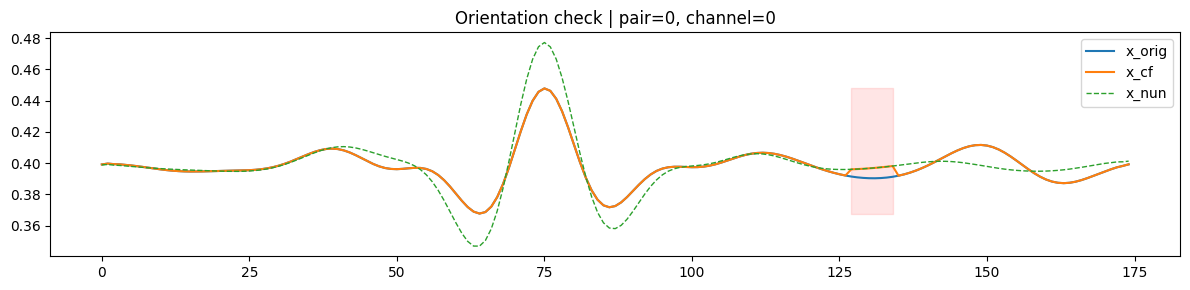

In [58]:
# --- Quick visual orientation check: selected pair 0, channel 0 ---
PAIR_INDEX = 0
CHANNEL_INDEX = 0

plt.figure(figsize=(12, 3))
plt.plot(x_orig_all[PAIR_INDEX, :, CHANNEL_INDEX], label="x_orig", linewidth=1.5)
plt.plot(x_cf_all[PAIR_INDEX, :, CHANNEL_INDEX], label="x_cf", linewidth=1.5)
if x_nun_all is not None:
    plt.plot(x_nun_all[PAIR_INDEX, :, CHANNEL_INDEX], label="x_nun", linestyle="--", linewidth=1.0)
changed = masks_all[PAIR_INDEX, :, CHANNEL_INDEX].astype(bool)
if changed.any():
    ymin = min(x_orig_all[PAIR_INDEX, :, CHANNEL_INDEX].min(), x_cf_all[PAIR_INDEX, :, CHANNEL_INDEX].min())
    ymax = max(x_orig_all[PAIR_INDEX, :, CHANNEL_INDEX].max(), x_cf_all[PAIR_INDEX, :, CHANNEL_INDEX].max())
    plt.fill_between(np.arange(changed.size), ymin, ymax, where=changed, color="red", alpha=0.10, step="mid")
plt.title(f"Orientation check | pair={PAIR_INDEX}, channel={CHANNEL_INDEX}")
plt.legend()
plt.tight_layout()
plt.show()


Original shape: (39, 175, 15)
Counterfactual shape: (39, 175, 15)
Mask shape: (39, 175, 15)
NUN shape: (39, 175, 15)
Delineation channel: 1
NeuroKit available: True
Reference window mode: union
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
Global morphology summary:


,metric,expected_direction,n_instance_channel_pairs,median_delta,q1,q3,mean_delta,std_delta,pct_in_expected_direction,wilcoxon_stat,wilcoxon_p
0,delta_q_amp,less,585,0.0,0.0,0.0,0.002264,0.013755,6.153846,4653.0,9.999497e-01
1,delta_q_extreme_abs,greater,585,0.0,0.0,0.0,-0.002903,0.016577,6.324786,1835.0,9.999773e-01
2,delta_st_level,greater,585,0.0,0.0,0.0,0.000010,0.000661,2.222222,175.0,3.683086e-01
3,delta_st_abs,greater,585,0.0,0.0,0.0,-0.000023,0.000529,2.222222,134.0,7.784138e-01
4,delta_st_q_contrast,greater,585,0.0,0.0,0.0,-0.002253,0.013776,6.666667,1894.0,9.999277e-01
5,delta_t_peak_abs,less,585,0.0,0.0,0.0,-0.000490,0.003749,17.777778,2772.0,5.249239e-07
6,delta_t_area_abs,less,585,0.0,0.0,0.0,-0.000285,0.002414,23.418803,10631.0,1.321874e-03


Per-channel summary:


,channel,n,delta_q_amp_median,delta_q_amp_q1,delta_q_amp_q3,delta_q_amp_pct_expected,delta_q_extreme_abs_median,delta_q_extreme_abs_q1,delta_q_extreme_abs_q3,delta_q_extreme_abs_pct_expected,delta_st_level_median,delta_st_level_q1,delta_st_level_q3,delta_st_level_pct_expected,delta_st_abs_median,delta_st_abs_q1,delta_st_abs_q3,delta_st_abs_pct_expected,delta_st_q_contrast_median,delta_st_q_contrast_q1,delta_st_q_contrast_q3,delta_st_q_contrast_pct_expected,delta_t_peak_abs_median,delta_t_peak_abs_q1,delta_t_peak_abs_q3,delta_t_peak_abs_pct_expected,delta_t_area_abs_median,delta_t_area_abs_q1,delta_t_area_abs_q3,delta_t_area_abs_pct_expected
0,0,39,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,15.384615,0.000000,0.000000,0.000000,15.384615
1,1,39,0.0,0.0,0.000000,10.256410,0.0,-0.000895,0.0,0.000000,0.0,0.0,0.0,2.564103,0.0,0.0,0.0,2.564103,0.0,0.000000,0.0,10.256410,0.0,-0.001892,0.000000,33.333333,0.000000,0.000000,0.000392,23.076923
2,2,39,0.0,0.0,0.000000,7.692308,0.0,0.000000,0.0,5.128205,0.0,0.0,0.0,2.564103,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,7.692308,0.0,0.000000,0.000699,5.128205,0.000000,0.000000,0.000628,5.128205
3,3,39,0.0,0.0,0.000000,7.692308,0.0,0.000000,0.0,7.692308,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,5.128205,0.0,-0.001091,0.000000,28.205128,0.000000,-0.000009,0.000228,25.641026
4,4,39,0.0,0.0,0.000000,2.564103,0.0,0.000000,0.0,2.564103,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.564103,0.0,0.000000,0.0,2.564103,0.0,0.000000,0.000000,5.128205,0.000000,0.000000,0.000000,7.692308
5,5,39,0.0,0.0,0.000000,2.564103,0.0,0.000000,0.0,2.564103,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.564103,0.0,0.000000,0.0,2.564103,0.0,0.000000,0.000000,12.820513,0.000000,0.000000,0.000122,10.256410
6,6,39,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,15.384615,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,5.128205,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,5.128205,0.000000,0.000000,0.000000,5.128205
7,7,39,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,5.128205,0.0,0.0,0.0,2.564103,0.0,0.0,0.0,2.564103,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,10.256410,0.000000,-0.002202,0.000000,41.025641
8,8,39,0.0,0.0,0.000000,12.820513,0.0,0.000000,0.0,12.820513,0.0,0.0,0.0,2.564103,0.0,0.0,0.0,5.128205,0.0,0.000000,0.0,12.820513,0.0,0.000000,0.000000,17.948718,0.000000,0.000000,0.000000,23.076923
9,9,39,0.0,0.0,0.000000,10.256410,0.0,0.000000,0.0,7.692308,0.0,0.0,0.0,2.564103,0.0,0.0,0.0,2.564103,0.0,0.000000,0.0,10.256410,0.0,0.000000,0.000000,20.512821,0.000000,0.000000,0.000000,20.512821


ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
ERRORRRRR!
Delineation source counts:


,delineation_source,orig_delineation_source,nun_delineation_source,n
0,fallback_centered,fallback_centered,fallback_centered,1


Mask overlap summary:


,region,median_changed_pct,q1,q3,mean_changed_pct,std_changed_pct
5,t,49.624060,21.179191,84.712644,52.083490,34.162996
2,q,20.512821,0.000000,42.358804,22.781141,23.394547
6,other,13.333333,5.430647,22.649573,15.215978,13.605325
0,baseline,0.000000,0.000000,0.000000,0.970763,5.444784
1,p,0.000000,0.000000,6.251619,4.132668,6.833049
3,r,0.000000,0.000000,7.299716,4.787924,8.287623
4,st,0.000000,0.000000,0.000000,0.524383,1.983389


Manuscript-style result sentences:
Q-window amplitude decreased: median delta = 0 [IQR 0, 0], 6.2% in the expected direction, one-sided Wilcoxon p = 0.9999.
Q-window absolute deviation increased: median delta = 0 [IQR 0, 0], 6.3% in the expected direction, one-sided Wilcoxon p = 1.0000.
ST-window level increased: median delta = 0 [IQR 0, 0], 2.2% in the expected direction, one-sided Wilcoxon p = 0.3683.
ST-window absolute deviation increased: median delta = 0 [IQR 0, 0], 2.2% in the expected direction, one-sided Wilcoxon p = 0.7784.
ST-Q contrast increased: median delta = 0 [IQR 0, 0], 6.7% in the expected direction, one-sided Wilcoxon p = 0.9999.
T-window peak absolute amplitude decreased: median delta = 0 [IQR 0, 0], 17.8% in the expected direction, one-sided Wilcoxon p = < 1e-4.
T-window mean absolute amplitude decreased: median delta = 0 [IQR 0, 0], 23.4% in the expected direction, one-sided Wilcoxon p = 0.0013.


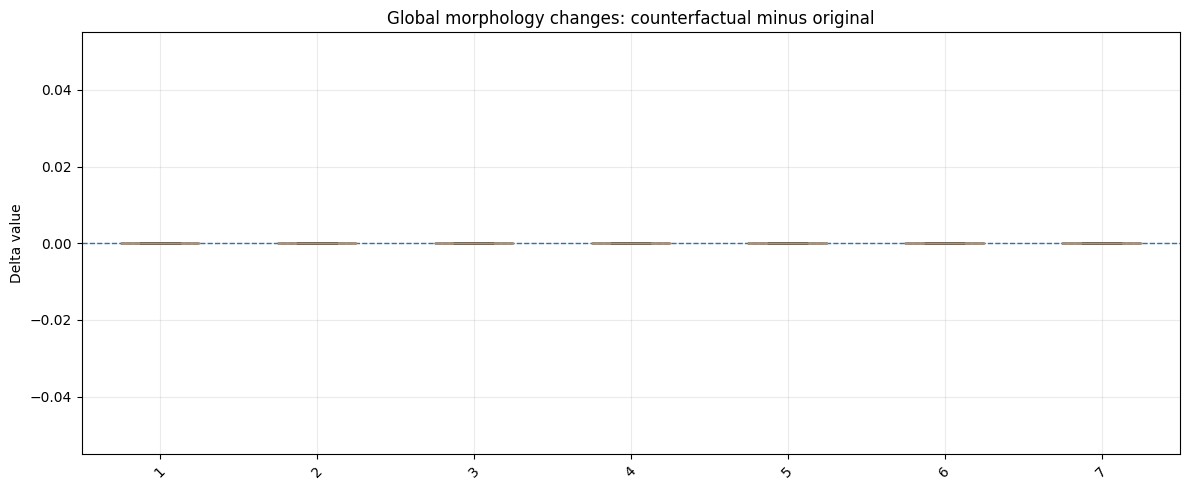

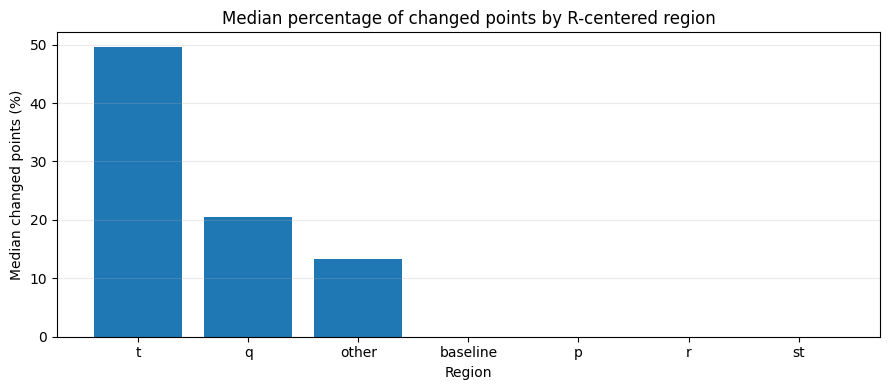

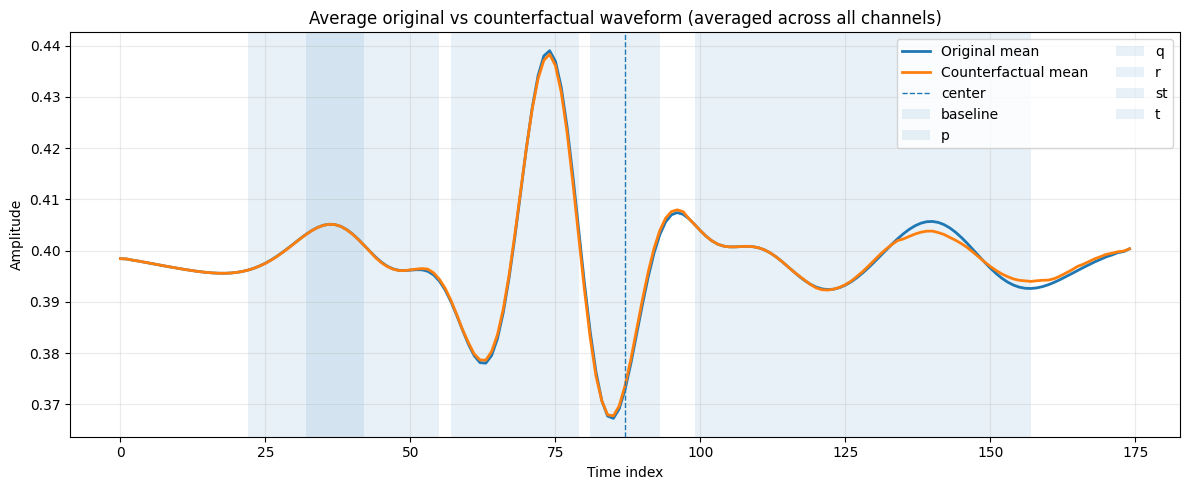

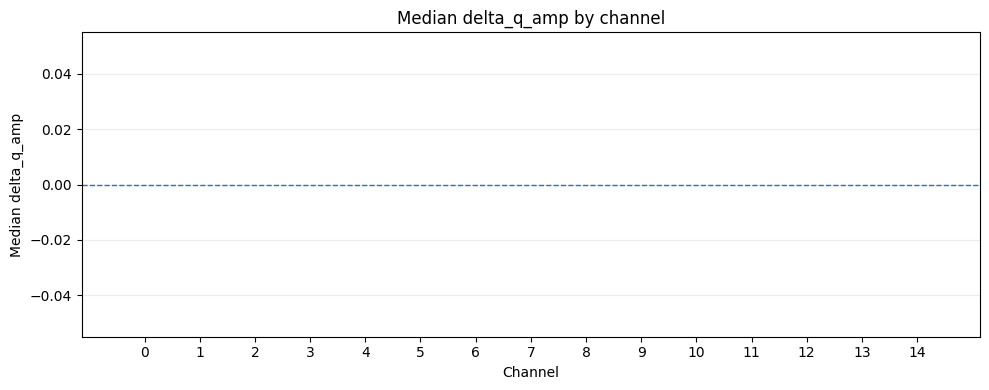

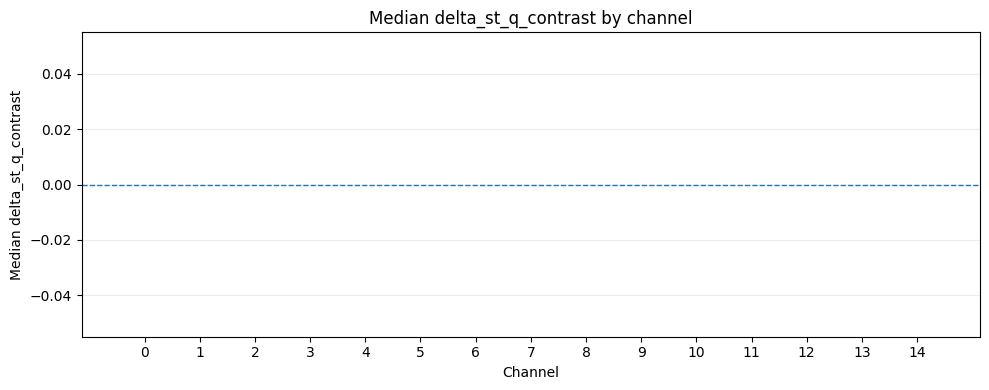

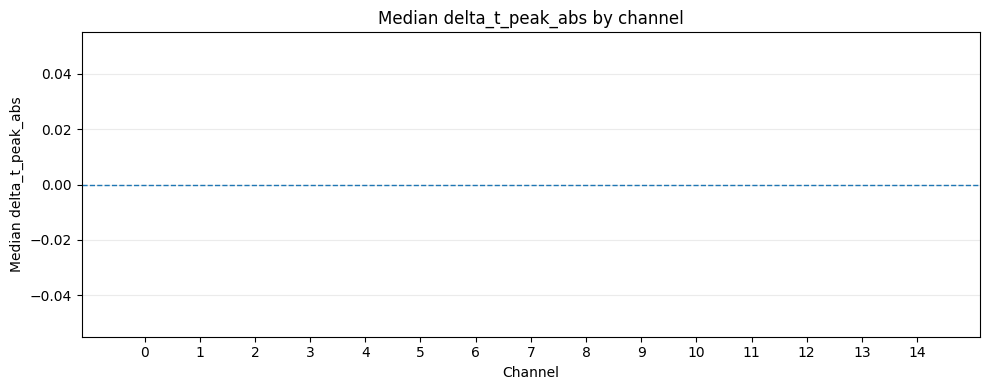

In [59]:
# --- Execute global morphology analysis on adapted arrays ---
# Delineation is derived from Lead II of x_orig and x_nun, then propagated to all channels.

if "ensure_time_channel" not in globals():
    def ensure_time_channel(x):
        return standardize_signal(x, name="analysis_signal")

if "ensure_batch_time_channel" not in globals():
    def ensure_batch_time_channel(x):
        arr = np.asarray(x)
        if arr.ndim == 2:
            arr = arr[None, :, :]
        if arr.ndim == 4 and arr.shape[1] == 1:
            arr = arr[:, 0]
        if arr.ndim != 3:
            raise ValueError(f"Expected batch with shape (n, time, channels), got {arr.shape}")
        first = standardize_signal(arr[0], name="batch_first")
        if first.shape == arr[0].shape:
            return arr
        if first.shape == arr[0].T.shape:
            return np.swapaxes(arr, 1, 2)
        return arr

x_orig_all = ensure_batch_time_channel(x_orig_all)
x_cf_all = ensure_batch_time_channel(x_cf_all)
masks_all = ensure_batch_time_channel(masks_all).astype(bool)
if x_nun_all is not None:
    x_nun_all = ensure_batch_time_channel(x_nun_all)

print("Original shape:", x_orig_all.shape)
print("Counterfactual shape:", x_cf_all.shape)
print("Mask shape:", masks_all.shape)
print("NUN shape:", None if x_nun_all is None else x_nun_all.shape)
print("Delineation channel:", ECG_DELINEATION_CHANNEL_IDX)
print("NeuroKit available:", NEUROKIT_AVAILABLE)
print("Reference window mode:", REFERENCE_WINDOW_MODE)

morphology_df = analyze_all_pairs_global(
    x_orig_all,
    x_cf_all,
    x_nun_all=x_nun_all,
    instance_ids=instance_ids,
)
global_summary = summarize_global_morphology(morphology_df)
channel_summary = summarize_by_channel(morphology_df)

print("Global morphology summary:")
display(global_summary)

print("Per-channel summary:")
display(channel_summary)

mask_overlap_df = mask_overlap_all(
    x_orig_all,
    x_cf_all,
    x_nun_all=x_nun_all,
    masks_all=masks_all,
    tolerance=MASK_TOLERANCE,
)
mask_overlap_summary = summarize_mask_overlap(mask_overlap_df)

print("Delineation source counts:")
display(morphology_df[["delineation_source", "orig_delineation_source", "nun_delineation_source"]].drop_duplicates().value_counts().reset_index(name="n"))

print("Mask overlap summary:")
display(mask_overlap_summary)

print("Manuscript-style result sentences:")
make_result_sentences(global_summary)

plot_global_delta_distributions(morphology_df)
plot_mask_overlap_summary(mask_overlap_summary)
plot_average_waveforms(x_orig_all, x_cf_all)

plot_per_channel_medians(morphology_df, "delta_q_amp")
plot_per_channel_medians(morphology_df, "delta_st_q_contrast")
plot_per_channel_medians(morphology_df, "delta_t_peak_abs")
